# Notebook to compute the LSST's passbands and the impact of the atmospheric parameters on the colors of reference sources 

In this notebook we are going to take the reference spectra from the pysynphot's spectral atlases and make them pass through the LSST's throughput and the simulated atmospheres from the previous notebooks. 

This notebook requires [pysynphot](https://pysynphot.readthedocs.io/en/latest/) 


# Load necessary packages 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
#import pysynphot as S
from scipy.interpolate import interp1d
from scipy import integrate
from astropy.io import fits
from scipy.optimize import curve_fit
import pandas as pd
#import quadpy

# allow interactive plots
#%matplotlib widget

In [2]:
import rubin_sim

In [3]:
#S.refs.showref()

# Define LaTeX commands 

$\newcommand{\AA}{\mathit{\unicode{x212B}}}$
Angstrom symbol: $\AA$

# Define functions and constants 

In [4]:
def calc_eff_lambda(wl,T):
    assert (np.isnan(T)==True).any()==False
    
    num_ = np.trapz(wl*T,x=wl)
    den_ = np.trapz(T,x=wl)
    
    return num_/den_

In [5]:
c_light = 2.99792458e+18 #angstrom/s
h_planck = 6.6262e-27 #erg s 

In [6]:
def flam_to_photlam(wl,flam):
    return flam*wl/(c_light*h_planck)

We check that this function actually creates a spectrum with the properties of an AB source, that is, a flat spectrum in fnu units (erg/s/cm2/Hz) 

In [7]:
# Reference flux value for an AB source in erg / s / cm2 / Hz 
f_ref = 3.631*10**(-20)

In [8]:
# Pivot wavelength [cm] 
wl_piv = 5.4929*10**(-5)

In [9]:
C = f_ref/(h_planck*wl_piv*10**8.)
print(C)

997.6082135645418


In [10]:
# The SED of an AB source (that is, constant flux in frequency units) expressed in photons / s / cm^2 / Angstrom 
def ABnphot(wl):
    #return 997.2*5500./wl
    return C*wl_piv*10**8./wl

In [11]:
def photlam_to_fnu(wl,photlam):
    return photlam*wl*h_planck

In [12]:
def fnu_to_photlam(wl,fnu):
    return fnu/(wl*h_planck)

Now, we define our function to compute the AB magnitudes: 

$$m_{AB} = -2.5 \log_{10} \frac{\int F_{\nu}^E(\lambda) \cdot S_{eff} \cdot t_{exp} \cdot S_{passband}(\lambda) \frac{d\lambda}{h \lambda}}{\int F_{\nu, AB}^E \cdot S_{eff} \cdot t_{exp} \cdot S_{throughput}(\lambda) \frac{d\lambda}{h \lambda}} = -2.5 \log_{10} \frac{\varphi}{\Phi_{AB}} \, . $$ 

Now, we want to compute the error for the AB magnitudes. The denominator is constant for a given $S_{throughput}(\lambda)$, so we assume it does not contribute to the error. Then, we can approximate $\varphi$ as 

$$\varphi \approx \sum_i F_{\nu}^E(\lambda_i) \cdot S_{eff} \cdot t_{exp} \cdot S_{passband}(\lambda_i) \frac{\Delta \lambda_i}{h \lambda_i} = \sum_i n_i \cdot S_{passband}(\lambda_i) \cdot \Delta \lambda_i \, , $$ 

where $n_i$ is 

$$n_i = \frac{F_{\nu}^E(\lambda_i) \cdot S_{eff} \cdot t_{exp}}{h \lambda_i} \, ,$$

the number of photo-electrons received within a given bin of wavelength, $\Delta \lambda_i$. Then, we can assume that $n_i$ is a Poisson random variable, so 

$$\sigma^2_{n_i} = n_i . $$ 

Taking this into account, we can write the error of $\varphi$ as 

$$\sigma^2_{\varphi} = \sum_i \left( \frac{\partial \varphi}{\partial n_i} \right)^2 \sigma^2_{n_i} = \sum_i n_i \cdot \left( S_{passband}(\lambda_i) \cdot \Delta \lambda_i \right)^2 \, , $$ 

Finally, the error on $m_{AB}$ is given by 
$$\sigma^2_{m_{AB}} = \left( \frac{\partial m_{AB}}{\partial \varphi} \right)^2 \sigma^2_{\varphi} = \left( \frac{-2.5}{\varphi \log 10} \right)^2 \cdot \sum_i n_i \cdot \left( S_{passband}(\lambda_i) \cdot \Delta \lambda_i \right)^2 \, . $$ 


In [13]:
def int_flux(spec,passband,filter=None,input_funits='photlam',return_mag=False,return_error=False,
             PhiAB=None,renormalize=None,verbose=False):
    if input_funits=='flam':
        if verbose:
            print('ATTENTION: converting flam units to photlam')
        spec = flam_to_photlam(wl_baseline,spec)
    elif input_funits=='fnu':
        if verbose:
            print('ATTENTION: converting fnu units to photlam')
        spec = fnu_to_photlam(wl_baseline,spec)
    #f_units = str(spec.fluxunits)
    #print(f_units)
    observation = spec*passband
    #if verbose:
    #    print('Observation units = ', observation.fluxunits)
    nan_mask = np.isnan(observation)
    
    obs_wave_ = wl_baseline[~nan_mask]
    obs_flux_ = observation[~nan_mask]
    #wave_min = np.min(observation.wave[~nan_mask])
    #wave_max = np.max(observation.wave[~nan_mask])
    
    if renormalize!=None:
        renorm = np.power(10.,-1.*renormalize/2.5)
    else:
        renorm = 1.0
    
    if input_funits=='fnu':
        num = np.trapz(obs_flux_*renorm/obs_wave_,x=obs_wave_)*Seff*exptime/h_planck
    elif input_funits=='photlam':
        num = np.trapz(obs_flux_*renorm,x=obs_wave_)*Seff*exptime
    
    if return_error:
        spec_fnu = photlam_to_fnu(wl_baseline,spec)
        
        finterp_pb = interp1d(wl_baseline,passband,bounds_error=False,fill_value=0.)
        pb_interp = finterp_pb(wl_baseline)
        
        delta_lambda = list(np.diff(wl_baseline))
        delta_lambda.append(wl_baseline[-1]-wl_baseline[-2])
        delta_lambda = np.array(delta_lambda)
        assert len(delta_lambda)==len(wl_baseline)
        
        n_i = spec_fnu*renorm*Seff*exptime/(wl_baseline*h_planck)
        print('n_i = ', n_i)
        #print('Number of collected photoelectrons = {0:.2e}'.format(np.sum(n_i*pb_interp)))
        err2_num = np.sum(n_i*(np.array(pb_interp)*delta_lambda)**2.)
    
    if verbose:
        print('Numerator = {0:.2e}'.format(num))
    if return_error and verbose:
        print('Variance of the numerator = {0:.2e}'.format(err2_num))
    
    if return_mag:
        
        if PhiAB is None:
            assert filter is not None
            flatsp_nphot = ABnphot(wl_baseline)
            #flatsp_ = S.ArraySpectrum(spec.wave, flatsp_nphot, name='Flat AB spectrum')
            flatsp_ = flatsp_nphot

            flatsp_ = photlam_to_fnu(wl_baseline,flatsp_)
            ab_obs = flatsp_*filter
            #if verbose:
            #    print('AB observation units = ', ab_obs.fluxunits)

            ab_wave_ = wl_baseline[~nan_mask]
            ab_flux_ = ab_obs[~nan_mask]

            den = np.trapz(ab_flux_/ab_wave_,x=ab_wave_)*Seff*exptime/h_planck
        else:
            den = PhiAB
            if verbose:
                print('ATTENTION: using external Phi_AB. Not computing it')

        if verbose:
            print('Denominator = {0:.2e}'.format(den))
        mab = -2.5*np.log10(num/den)
        if verbose:
            print('AB magnitude = ', mab)
            print('---------')
    
    if return_mag==False:
        if return_error:
            return num,np.sqrt(err2_num)
        else:
            return num
    else:
        if return_error:
            err2_mab = (2.5**2./np.log(10.)**2.)*err2_num/num**2.
            err_mab = np.sqrt(err2_mab)
            return num,mab,np.sqrt(err2_num),err_mab
        else:
            return num,mab
    

# Set LSST's parameters 

In [14]:
WLMIN=3400. # Minimum wavelength : PySynPhot works with Angstrom
WLMAX=10600. # Minimum wavelength : PySynPhot works with Angstrom

NBINS=int(WLMAX-WLMIN) # Number of bins between WLMIN and WLMAX
BinWidth=(WLMAX-WLMIN)/float(NBINS) # Bin width in Angstrom
WL=np.linspace(WLMIN,WLMAX,NBINS)   # Array of wavelength in Angstrom
# from key numbers
Reff=642.3/2. # effective radius in cm
Seff= np.pi*Reff**2  # in cm2
print(Seff)
exptime=30.0

324015.4546769212


In [15]:
#S.refs.setref(area=Seff, waveset=None) # set by default to 6.4230 m effective aperture 
#S.refs.set_default_waveset(minwave=WLMIN, maxwave=WLMAX, num=NBINS, delta=BinWidth, log=False)
#S.refs.showref()

# Set wavelength units 

In [16]:
waveunits = 'angstrom'
wavelabel = r'$\AA$'

# Define general paths 

In [17]:
print(os.getcwd())

/home/m/monroy/repos/auxtel_atm_color_comp


In [18]:
outdir_plots0 = 'output_plots'
if os.path.exists(outdir_plots0)==False:
    os.mkdir(outdir_plots0)
outdir_files = 'output_files/'
if os.path.exists(outdir_files)==False:
    os.mkdir(outdir_files)

# Load LSST's throughput 

https://github.com/lsst/throughputs/tree/main/baseline

In [19]:
throughput_path = 'data/lsst/'
throughput_label = 'hardware_{0}.dat'

In [20]:
filters = ['u','g','r','i','z','Y']
filter_names = {0:'u',1:'g',2:'r',3:'i',4:'z',5:'Y'}
filter_colors = {0:'b',1:'g',2:'darkgreen',3:'orange',4:'darkorange',5:'r'}

Write the throughputs in pysynphot format 

In [21]:
lsst_wl0 = []
lsst_bp0 = []
for i,f in enumerate(filters):
    throughput_ = np.loadtxt(throughput_path+throughput_label.format(f.lower()))
    
    wl = throughput_[:,0]*10.
    lsst_wl0.append(wl)
    lsst_bp0.append(throughput_[:,1])
    #assert str(lsst_bp0[i].waveunits)==waveunits


<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_7334/1921326836.py:7: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)


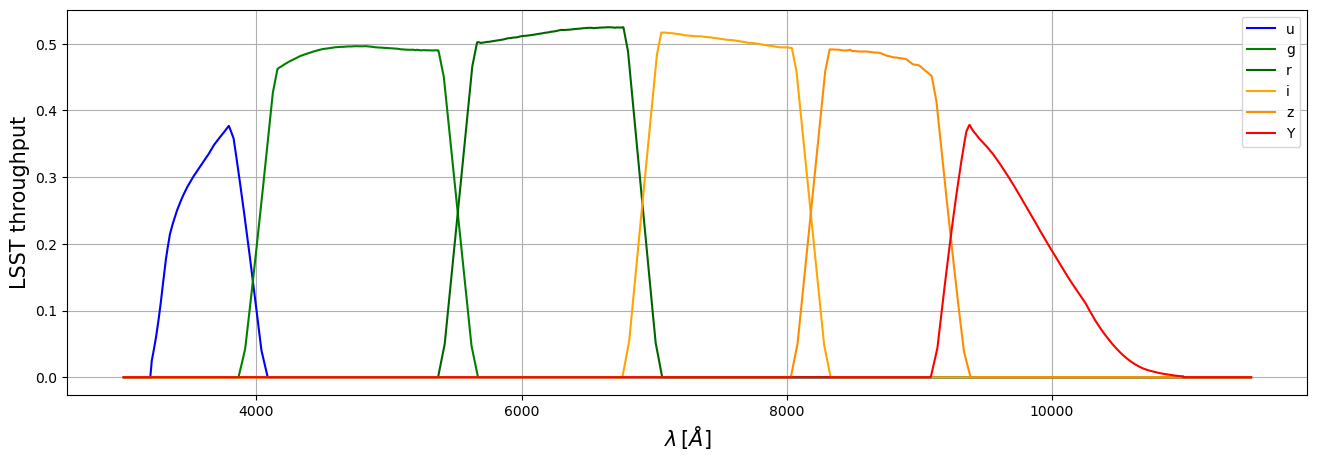

In [22]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)
for index in range(len(lsst_bp0)):
    ax.plot(lsst_wl0[index],lsst_bp0[index],label=filter_names[index],color=filter_colors[index])
    
ax.grid()
plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
plt.ylabel('LSST throughput',fontsize=15)
plt.legend()

### We introduce $\lambda_0$ and $\lambda_{\infty}$ for later purposes 

In [23]:
lambda_0 = 0.0
lambda_inf = 1.4e4

In [24]:
wl_baseline = np.arange(lambda_0+1.,lambda_inf)
print(len(wl_baseline),wl_baseline[0],wl_baseline[-1])

13999 1.0 13999.0


In [25]:
wl_baseline

array([1.0000e+00, 2.0000e+00, 3.0000e+00, ..., 1.3997e+04, 1.3998e+04,
       1.3999e+04], shape=(13999,))

Text(0, 0.5, 'Flux [Jy]')

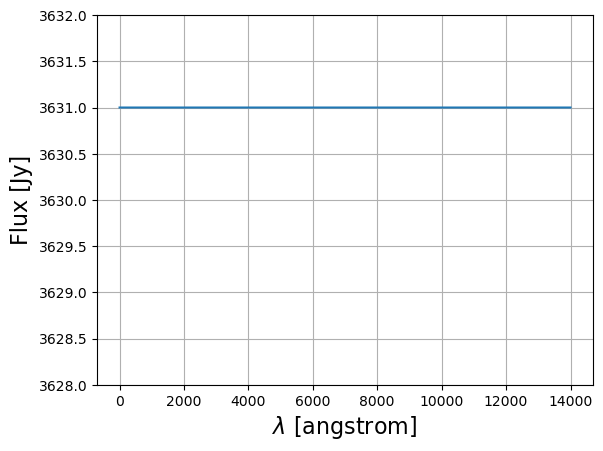

In [26]:
checkab = ABnphot(wl_baseline)
#checkab_ = S.ArraySpectrum(test_sed.wave, checkab, name='Flat AB spectrum')
#plt.plot(checkab_.wave,checkab_.flux)
#checkab_.convert('fnu')
checkab_ = photlam_to_fnu(wl_baseline,checkab)
plt.plot(wl_baseline,checkab_*10**23.)
plt.ylim(3.628*10.**3,3.632*10**3.)
plt.grid()
plt.xlabel(r'$\lambda$ [angstrom]',fontsize=16)
plt.ylabel('Flux [Jy]',fontsize=16)

In [27]:
flatsp_nphot = ABnphot(wl_baseline)

In [28]:
#flat_spec = S.ArraySpectrum(test_sed.wave, flatsp_nphot, name='Flat AB spectrum')
flat_spec = flatsp_nphot

In [29]:
#flat_spec.fluxunits

## Effective wavelengths 

For each filter we can define the effective wavelength, $\lambda_b^{eff}$, as 

$$\lambda_b^{eff} = \frac{\int \lambda \, T_{tel,b}(\lambda) \, d\lambda}{\int T_{tel,b}(\lambda) \, d\lambda} \, . $$

# Interpolate all filters to evaluate them at $\lambda_{baseline}$ 

In [30]:
lsst_bp = []
eff_lambda = {}
for fi_ in range(len(filters)):
    print(filters[fi_])
    wl_ = lsst_wl0[fi_]
    T_ = lsst_bp0[fi_]
    T_[T_<=1e-3] = 0.
    
    finterp_ = interp1d(wl_,T_,bounds_error=False,fill_value=0.)
    T_2 = finterp_(wl_baseline)
    
    lsst_bp.append(T_2)
    eff_wl_ = calc_eff_lambda(wl_baseline,T_2)
    eff_lambda[filters[fi_]] = eff_wl_
    

u
g
r
i
z
Y


/tmp/ipykernel_7334/1015743673.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num_ = np.trapz(wl*T,x=wl)
/tmp/ipykernel_7334/1015743673.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den_ = np.trapz(T,x=wl)


In [31]:
eff_lambda

{'u': np.float64(3646.662679925946),
 'g': np.float64(4775.691487833466),
 'r': np.float64(6221.859926396509),
 'i': np.float64(7538.740989090991),
 'z': np.float64(8695.989678941447),
 'Y': np.float64(9703.267866775377)}

<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_7334/2565286318.py:8: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)


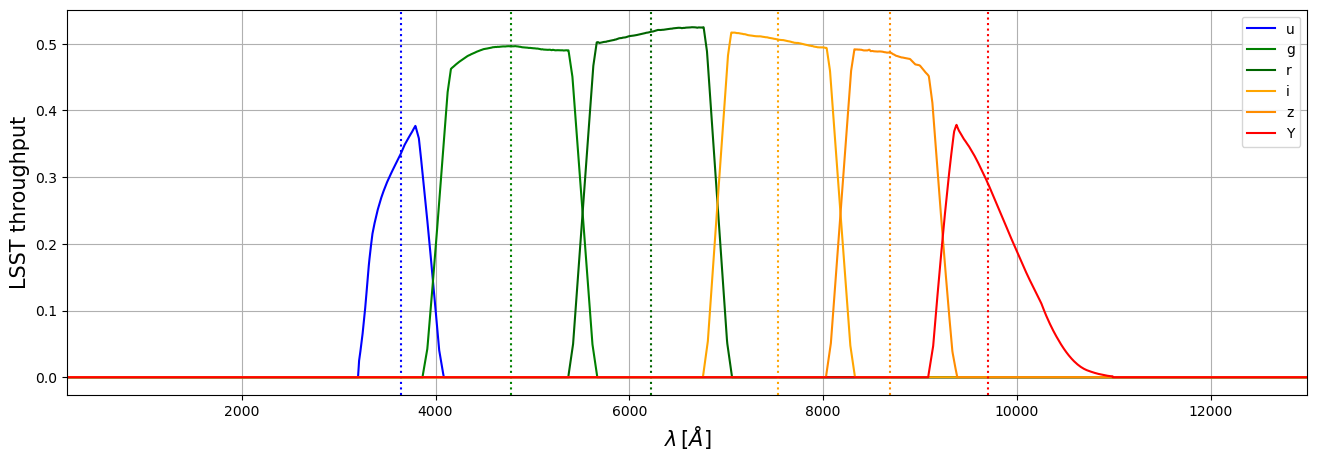

In [32]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)
for i,filter in enumerate(filters):
    ax.plot(wl_baseline,lsst_bp[i],label=filter_names[i],color=filter_colors[i])
    ax.axvline(x=eff_lambda[filter],ls=':',color=filter_colors[i],alpha=1.0)
ax.set_xlim(200,13000)
ax.grid()
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('LSST throughput',fontsize=15)
ax.legend()

To avoid computing $\Phi_{AB}$ each time, we define that integral once and we give it to our function each time it is needed 

In [33]:
Phi_AB = []
for filter in lsst_bp:
    Phi_AB_b = int_flux(flat_spec,filter)
    Phi_AB.append(Phi_AB_b)
    print(Phi_AB_b)
Phi_AB = np.array(Phi_AB)

3089231345551.3145
8221965111018.64
6162301363744.427
4553830920904.092
3082551619550.685
1648265446549.434


/tmp/ipykernel_7334/1051446165.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(obs_flux_*renorm,x=obs_wave_)*Seff*exptime


### We verify that that the AB magnitude of a flat AB spectrum is 0

In [34]:
for filter in lsst_bp:
    nn,mm = int_flux(flat_spec,filter,filter=filter,input_funits='photlam',return_mag=True,verbose=True)
    #print(nn,mm)

Numerator = 3.09e+12
Denominator = 3.09e+12
AB magnitude =  -4.821637332766435e-16
---------
Numerator = 8.22e+12
Denominator = 8.22e+12
AB magnitude =  -0.0
---------
Numerator = 6.16e+12
Denominator = 6.16e+12
AB magnitude =  -2.4108186663832173e-16
---------
Numerator = 4.55e+12
Denominator = 4.55e+12
AB magnitude =  -2.4108186663832173e-16
---------
Numerator = 3.08e+12
Denominator = 3.08e+12
AB magnitude =  -2.4108186663832173e-16
---------
Numerator = 1.65e+12
Denominator = 1.65e+12
AB magnitude =  -0.0
---------


/tmp/ipykernel_7334/1051446165.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(obs_flux_*renorm,x=obs_wave_)*Seff*exptime
/tmp/ipykernel_7334/1051446165.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den = np.trapz(ab_flux_/ab_wave_,x=ab_wave_)*Seff*exptime/h_planck


In [35]:
for i,filter in enumerate(lsst_bp):
    nn,mm = int_flux(flat_spec,filter,input_funits='photlam',return_mag=True,verbose=True,PhiAB=Phi_AB[i])
    #print(nn,mm)

Numerator = 3.09e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 3.09e+12
AB magnitude =  -0.0
---------
Numerator = 8.22e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 8.22e+12
AB magnitude =  -0.0
---------
Numerator = 6.16e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 6.16e+12
AB magnitude =  -0.0
---------
Numerator = 4.55e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 4.55e+12
AB magnitude =  -0.0
---------
Numerator = 3.08e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 3.08e+12
AB magnitude =  -0.0
---------
Numerator = 1.65e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 1.65e+12
AB magnitude =  -0.0
---------


/tmp/ipykernel_7334/1051446165.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(obs_flux_*renorm,x=obs_wave_)*Seff*exptime


# Load simulated transparencies 

Select variable parameter and specify airmass and clouds 

In [36]:
variable_param = 'pwv'
am0 = 1.2
cloud0 = 0.0
pwv0 = 3.0
aero0 = 0.04

Specify which distribution follows the simulated parameter. Options: 
* linear_distribution-discrete: generated following a linear function and with pre-established step (e.g., PWV = 1.0, 2.0, 3.0, ....) 
* linear_distribution-continuous: generated following a linear function and specifying only the value range and number of simulations (e.g., PWV = 1.0, 1.25, 1.5, ....) 
* uniform_distribution: generated following a uniform random distribution (work in progress) 
* specific_distribution: generated following random distributions specific to each parameter (work in progress) 


In [37]:
param_dist = 'linear_distribution-discrete'

In [38]:
outdir_plots_ = os.path.join('output_plots/',param_dist.split('-')[0])
if os.path.exists(outdir_plots_)==False:
    os.mkdir(outdir_plots_)

outdir_plots = os.path.join('output_plots/',param_dist.replace('-','/'))
if os.path.exists(outdir_plots)==False:
    os.mkdir(outdir_plots)

In [39]:
if variable_param=='airmass' or variable_param=='cloud':
    t_file = 'simulated_transparencies_varying_{0}.fits'.format(variable_param)
    t_file_ref = 'simulated_transparencies_varying_{0}_ref.fits'.format(variable_param)
else:
    t_file = 'simulated_transparencies_varying_{0}_airmass_{1}_cloud_{2}.fits'.format(variable_param,am0,cloud0)
    t_file_ref = 'simulated_transparencies_varying_{0}_airmass_{1}_cloud_{2}_ref.fits'.format(variable_param,am0,cloud0)

t_path = os.path.join('./simulated_transparencies/',param_dist.replace('-','/'))
t_in = os.path.join(t_path,t_file)
t_in_ref = os.path.join(t_path,t_file_ref)
t = fits.open(t_in)
t_ref = fits.open(t_in_ref)

In [40]:
head = t[0].header
data = t[0].data
print(data.shape)
data_ref = t_ref[0].data
print(data_ref.shape)

(10, 956)
(2, 956)


In [41]:
n_atmp = head['ID_RES']
n_sim = head['NTRANSP']
print(n_atmp, n_sim)

5 9


In [42]:
wl_t = data[0][n_atmp:]*10.

<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_7334/3796105917.py:8: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel('$\\lambda \,$'+'[angstrom]',fontsize=15)


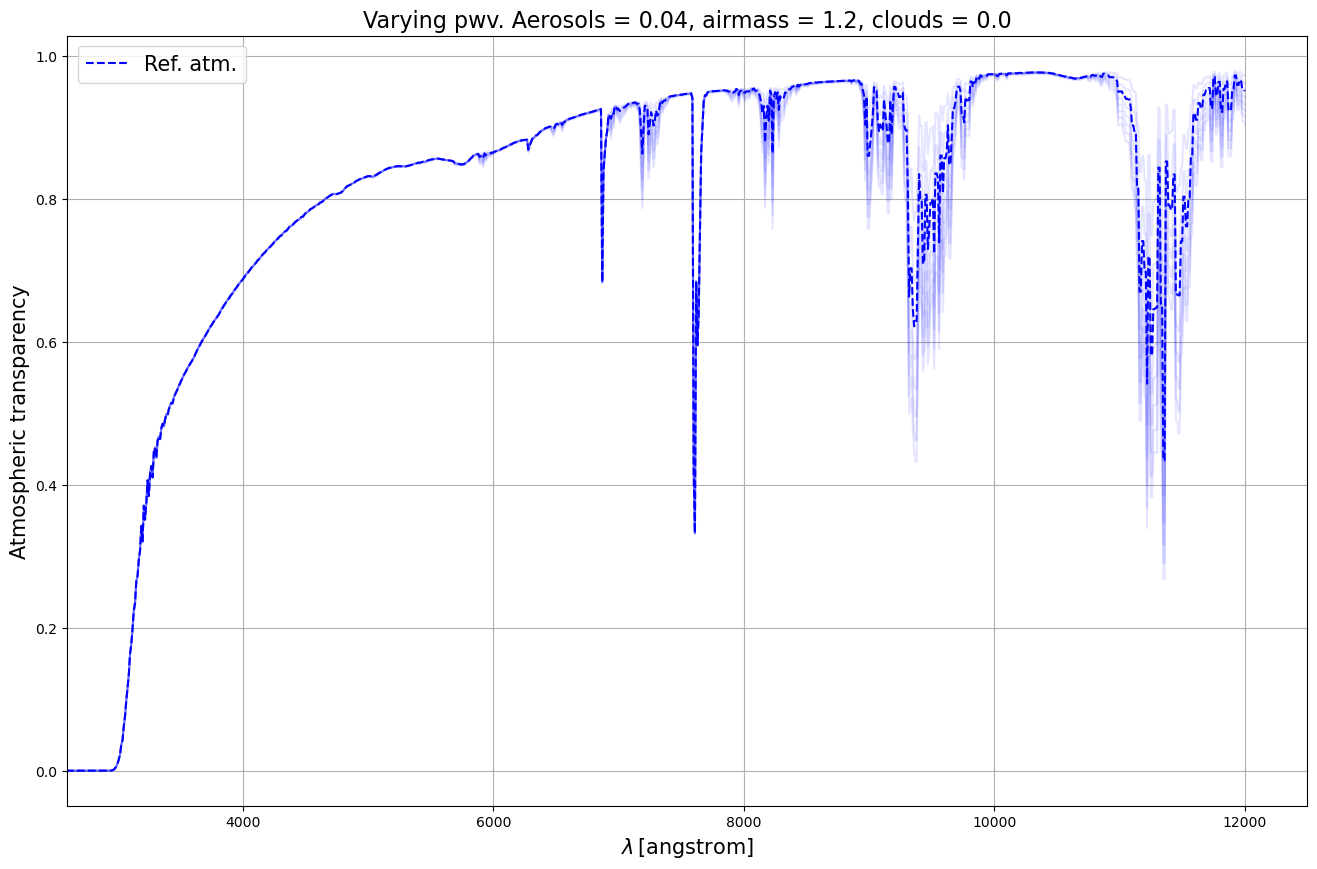

In [43]:
fig=plt.figure(figsize=(16,10))
ax = fig.add_subplot(111)
for atm_i in range(1,n_sim):
    ax.plot(wl_t,data[atm_i][n_atmp:],color='b',alpha=0.1)
ax.plot(wl_t,data_ref[1][n_atmp:],ls='--',color='b',label='Ref. atm.')
plt.xlim(2600.,12500.)
plt.grid()
plt.xlabel('$\\lambda \,$'+'[angstrom]',fontsize=15)
plt.ylabel('Atmospheric transparency',fontsize=15)
plt.title('Varying {0}. Aerosols = {1}, airmass = {2}, clouds = {3}'.format(variable_param,aero0,am0,cloud0),fontsize=16)
plt.legend(fontsize=15)
plt.savefig(os.path.join(outdir_plots,'atm_transparencies_varying_{0}_airmass_{1}_clouds_{2}.png'.format(variable_param,am0,cloud0)))

# Check range of values of variable parameter 

In [44]:
print(head)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  956                                                  NAXIS2  =                   10                                                  NTRANSP =                    9                                                  ID_AM   =                    4                                                  ID_VAOD =                    1                                                  ID_PWV  =                    0                                                  ID_O3   =                    2                                                  ID_CLD  =                    3                                                  ID_RES  =                    5                                                  END                                     

In [45]:
params_index = {'pwv':0,'aerosol':1,'ozone':2,'cloud':3,'airmass':4}

In [46]:
var_index = params_index[variable_param]

In [47]:
#data[1:,1]
data[1:,var_index]

array([1., 2., 3., 4., 5., 6., 7., 8., 9.], dtype='>f8')

# Select data for variable parameter of these simulations 

In [48]:
atm_vals = data[1:,var_index]

In [49]:
np.save('output_files/atm_vals_{0}_airmass_{1}_cloud_{2}.npy'.format(variable_param,am0,cloud0),atm_vals)

# Interpolate simulated transparencies 

In [50]:
atm_transp = []
for i in range(1,n_sim+1):
    finterp_i = interp1d(wl_t,data[i][n_atmp:],bounds_error=False,fill_value=0.)
    atm_interp_i = finterp_i(wl_baseline)
    #atm_i = S.ArrayBandpass(wl_t,data[i][n_atmp:], name='Atm. transp. {0}'.format(i))
    #atm_i = S.ArrayBandpass(wl_baseline,atm_interp_i, name='Atm. transp. {0}'.format(i))
    #assert str(atm_i.waveunits)==waveunits
    atm_transp.append(atm_interp_i)

In [51]:
finterp_ref = interp1d(wl_t,data_ref[1][n_atmp:],bounds_error=False,fill_value=0.)
atm_interp_ref = finterp_ref(wl_baseline)
#atm_i = S.ArrayBandpass(wl_t,data[i][n_atmp:], name='Atm. transp. {0}'.format(i))
#atm_transp_ref = S.ArrayBandpass(wl_baseline,atm_interp_ref, name='Atm. transp. {0}'.format(i))
#assert str(atm_transp_ref.waveunits)==waveunits
atm_transp_ref = atm_interp_ref

<>:9: SyntaxWarning: invalid escape sequence '\,'
<>:9: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_7334/2918690455.py:9: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \,$'+'[angstrom]',fontsize=15)


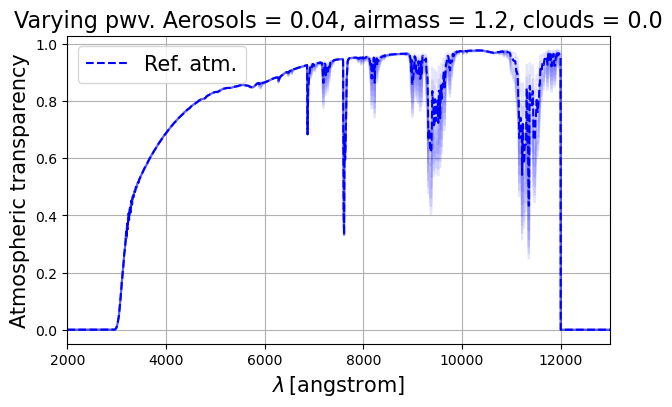

In [52]:
fig=plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)
for i in range(n_sim):
    ax.plot(wl_baseline,atm_transp[i],color='b',alpha=0.1)
ax.plot(wl_baseline,atm_transp_ref,ls='--',color='b',label='Ref. atm.')
#plt.xlim(2600.,12500.)
ax.grid()
ax.set_xlim(2000,13000)
ax.set_xlabel('$\\lambda \,$'+'[angstrom]',fontsize=15)
ax.set_ylabel('Atmospheric transparency',fontsize=15)
ax.set_title('Varying {0}. Aerosols = {1}, airmass = {2}, clouds = {3}'.format(variable_param,aero0,am0,cloud0),fontsize=16)
ax.legend(fontsize=15)

# Compute total bandpass (atmosphere(s) x LSST throughput) 

In [53]:
total_passband = {}
#for bpname in filters:
#    total_passband[bpname] = []

for index,bp in enumerate(lsst_bp):
    total_passband[filters[index]] = []
    for i in range(n_sim):
        total_pass = bp*atm_transp[i]
        total_passband[filters[index]].append(total_pass)

In [54]:
total_passband_ref = {}
for index,bp in enumerate(lsst_bp):
    total_pass = bp*atm_transp_ref
    total_passband_ref[filters[index]] = total_pass

In [55]:
print(len(total_passband['u']))
print(total_passband['u'][0])

9
[0. 0. 0. ... 0. 0. 0.]


<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_7334/1980352437.py:13: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)


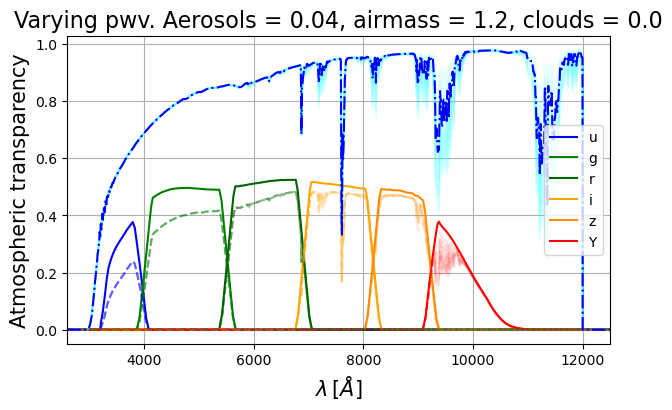

In [56]:
fig=plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)
for index,bp in enumerate(lsst_bp):
    ax.plot(wl_baseline,bp,label=filter_names[index],color=filter_colors[index])

for isim in range(n_sim):
    ax.plot(wl_baseline,atm_transp[isim],alpha=0.1,color='cyan')
    for index,bpname in enumerate(filters):
        ax.plot(wl_baseline,total_passband[bpname][isim],ls='--',color=filter_colors[index],alpha=0.1)
ax.plot(wl_baseline,atm_transp_ref,ls='-.',color='b')        
ax.set_xlim(2600.,12500.)
ax.grid()
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('Atmospheric transparency',fontsize=15)
ax.legend()
ax.set_title('Varying {0}. Aerosols = {1}, airmass = {2}, clouds = {3}'.format(variable_param,aero0,am0,cloud0),fontsize=16)
plt.savefig(os.path.join(outdir_plots,'total_passbands_varying_{0}_airmass_{1}_clouds_{2}.png'.format(variable_param,am0,cloud0)))

Plot the atmospheric transparencies corresponding to the minimum and maximum atmospheric parameter that we are varying: 

In [57]:
min_val_ = np.min(atm_vals)
max_val_ = np.max(atm_vals)
ref_val_ = eval('{0}0'.format(variable_param))
print(min_val_,max_val_,ref_val_)

1.0 9.0 3.0


In [58]:
min_ind_ = np.where(atm_vals==min_val_)[0][0]
max_ind_ = np.where(atm_vals==max_val_)[0][0]
ref_ind_ = np.where(atm_vals==ref_val_)[0][0]

In [59]:
atm_transp[min_ind_]

array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,))

In [60]:
min_transp = atm_transp[min_ind_]
max_transp = atm_transp[max_ind_]
ref_transp = atm_transp[ref_ind_]

<>:5: SyntaxWarning: invalid escape sequence '\,'
<>:5: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_7334/150916002.py:5: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)


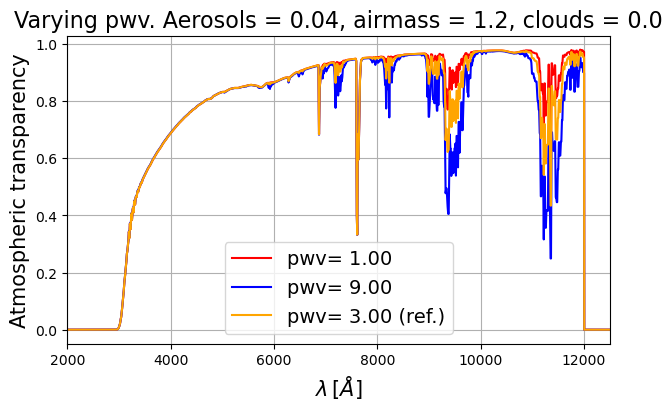

In [61]:
fig=plt.figure(figsize=(7,4))
plt.plot(wl_baseline,min_transp,color='r',label=variable_param+'= {0:.2f}'.format(min_val_))
plt.plot(wl_baseline,max_transp,color='b',label=variable_param+'= {0:.2f}'.format(max_val_))
plt.plot(wl_baseline,ref_transp,color='orange',label=variable_param+'= {0:.2f} (ref.)'.format(ref_val_))
plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
plt.ylabel('Atmospheric transparency',fontsize=15)
plt.xlim(2000,12500)
plt.grid()
plt.legend(fontsize=14)
plt.title('Varying {0}. Aerosols = {1}, airmass = {2}, clouds = {3}'.format(variable_param,aero0,am0,cloud0),fontsize=16)
plt.savefig(os.path.join(outdir_plots,'atm_transparencies_varying_{0}_airmass_{1}_clouds_{2}_min_max_values.png'.format(variable_param,am0,cloud0)))

# Define paths to spectral atlases (TRAINING)

In [62]:
phoenix_dir0 = '/home/m/monroy/External/pysynphot_data/grp/redcat/trds/grid/phoenix/'
sub_dirs = [dir_ for dir_ in os.listdir(phoenix_dir0) if 'phoenix' in dir_]
sub_dirs

['phoenixm15',
 'phoenixm20',
 'phoenixp05',
 'phoenixm40',
 'phoenixm30',
 'phoenixm10',
 'phoenixm25',
 'phoenixp03',
 'phoenixm00',
 'phoenixm35',
 'phoenixm05']

In [ ]:
train_dict = {}
for i,dir_ in enumerate(sub_dirs):
    files_ = [f for f in os.listdir(os.path.join(phoenix_dir0,dir_)) if '.fits' in f]
    for file_ in files_:
        spec_ = fits.open(os.path.join(phoenix_dir0,dir_,file_))
        wl_train = spec_[1].data['WAVELENGTH'].byteswap().view(spec_[1].data['WAVELENGTH'].dtype.newbyteorder())
        for col_ in spec_[1].data.dtype.names[1:]:
            data_ = spec_[1].data[col_].byteswap().view(spec_[1].data[col_].dtype.newbyteorder())
            #data_ = flam_to_photlam(wl_train,data_)
            finterp_ = interp1d(wl_train,data_,bounds_error=False,fill_value=0.)
            interp_spec_ = finterp_(wl_baseline)
            train_dict[file_.replace('.fits','')] = interp_spec_ 

In [64]:
len(train_dict.keys())

1562

In [65]:
list(train_dict.keys())[0]

'phoenixm15_4200'

(3400.0, 10600.0)

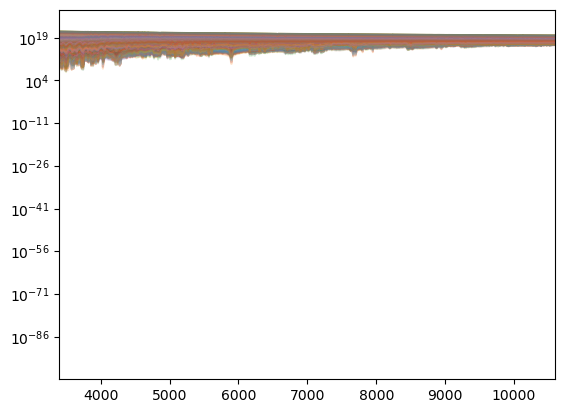

In [66]:
for key_ in list(train_dict.keys()):
    plt.plot(wl_baseline,train_dict[key_],alpha=0.2)
plt.yscale("log")
plt.xlim(WLMIN,WLMAX)

# Define paths to spectral atlases (DATA)

In [78]:
path_dict = {
    #'calspec':os.path.join(pysynphot_root_path,'calspec'),
    #'bpgs':os.path.join(pysynphot_root_path,'grid/bpgs'),
    #'jacobi':os.path.join(pysynphot_root_path,'grid/jacobi'),
    'pickles':'/home/m/monroy/rubin-user/pickles/dat_uvk'
}

atlas_dir = 'spectral_atlases/'
file_dict = {
    'calspec':'',
    'bpgs':os.path.join(atlas_dir,'atlas_bpgs.txt'),
    'jacobi':os.path.join(atlas_dir,'atlas_jacoby.txt'),
    'pickles':os.path.join(atlas_dir,'atlas_pickles.txt')
}


# Select a spectral atlas 

Options: 
* calspec (HST calibration spectra): work in progress, need to separate stars from AGNs and other sources 
* bpgs (Bruzual-Persson-Gunn-Stryker): 175 spectra 
* jacobi (Jacoby-Hunter-Christian): 161 spectra 
* pickles (Pickles): 131 spectra 

In [79]:
atlas_name = 'pickles'

atlas_path = path_dict[atlas_name]
atlas_file = file_dict[atlas_name]

In [80]:
atlas_path

'/home/m/monroy/rubin-user/pickles/dat_uvk'

# Find the spectra files and information 

In [81]:
#path_sed_calspec=os.path.join(pysynphot_root_path,'calspec')
atlas_seds = pd.read_csv(atlas_file)
atlas_seds

,File,Type,Teff,Name
0,pickles_uk_1.fits,O5V,39810.70,unknown
1,pickles_uk_2.fits,O9V,35481.40,unknown
2,pickles_uk_3.fits,B0V,28183.80,unknown
3,pickles_uk_4.fits,B1V,22387.20,unknown
4,pickles_uk_5.fits,B3V,19054.60,unknown
...,...,...,...,...
126,pickles_uk_127.fits,G8I,4591.98,unknown
127,pickles_uk_128.fits,K2I,4255.98,unknown
128,pickles_uk_129.fits,K3I,NaN,unknown
129,pickles_uk_130.fits,K4I,3990.25,unknown


# Load the spectra from the selected atlas and interpolate to evaluate at $\lambda_{baseline}$ 

In [82]:
sed_list = []
for sed_ in np.array(atlas_seds['File']):
    sed_list.append(sed_.replace('.fits',''))
print(len(sed_list))

131


In [91]:
sed_dict = {}
type_dict = {}
wl_same = []
for i,sed in enumerate(sed_list):
    #print('-------')
    #print(sed)
    wl0_ = fits.open(os.path.join(atlas_path,sed+'.fits'))[1].data['WAVELENGTH']
    spec0_ = fits.open(os.path.join(atlas_path,sed+'.fits'))[1].data['FLUX']
    spec0_ = flam_to_photlam(wl0_,spec0_)
    '''
    #print(spec0_.fluxunits)
    assert str(spec0_.waveunits)==waveunits
    wl_same.append((spec0_.wave==wl_spec_0).all())
    '''
    finterp_ = interp1d(wl0_,spec0_,bounds_error=False,fill_value=0.)
    interp_spec_ = finterp_(wl_baseline)
    #spec_ = S.ArraySpectrum(wl_baseline,interp_spec_)
    #spec_.convert('photlam')
    sed_dict[sed] = interp_spec_
    type_dict[sed] = atlas_seds['Type'][i]
    


# Define also the spectral types 

In [92]:
spectral_types = ['O','B','A','F','G','K','M']
categories = {}
for i in range(len(spectral_types)):
    categories[spectral_types[i]] = i+10
categories

{'O': 10, 'B': 11, 'A': 12, 'F': 13, 'G': 14, 'K': 15, 'M': 16}

<img align="center" src = Stellar_Classification_Chart.png width=750 style="padding: 10px"> 

https://upload.wikimedia.org/wikipedia/commons/3/37/Stellar_Classification_Chart.png

# Organise spectra by spectral type 

In [93]:
spec_by_type = {}
for i in range(len(spectral_types)):
    spec_type = spectral_types[i]
    
    spec_by_type[spec_type] = []
    for sed_ in type_dict.keys():
        if spec_type in type_dict[sed_]:
            spec_by_type[spec_type].append(sed_dict[sed_])


In [94]:
spec_cat = []
for sed_ in type_dict.keys():
    for type_ in spectral_types:
        if type_ in type_dict[sed_]:
            spec_cat.append(categories[type_])

spec_cat = np.array(spec_cat)

In [95]:
spec_cat

array([10, 10, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15,
       15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 11, 11, 12, 12, 13, 13,
       13, 14, 14, 14, 14, 15, 15, 15, 10, 11, 11, 11, 11, 12, 12, 12, 12,
       13, 13, 13, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 11, 11, 13, 13, 14, 15, 15, 16, 11, 11, 11, 11, 11, 12,
       12, 13, 13, 13, 14, 14, 14, 14, 15, 15, 15, 16])

Now we can plot them by spectral type separately 

In [96]:
type_colors = {'O':'b','B':'dodgerblue','A':'cyan','F':'g','G':'gold','K':'r','M':'brown'}

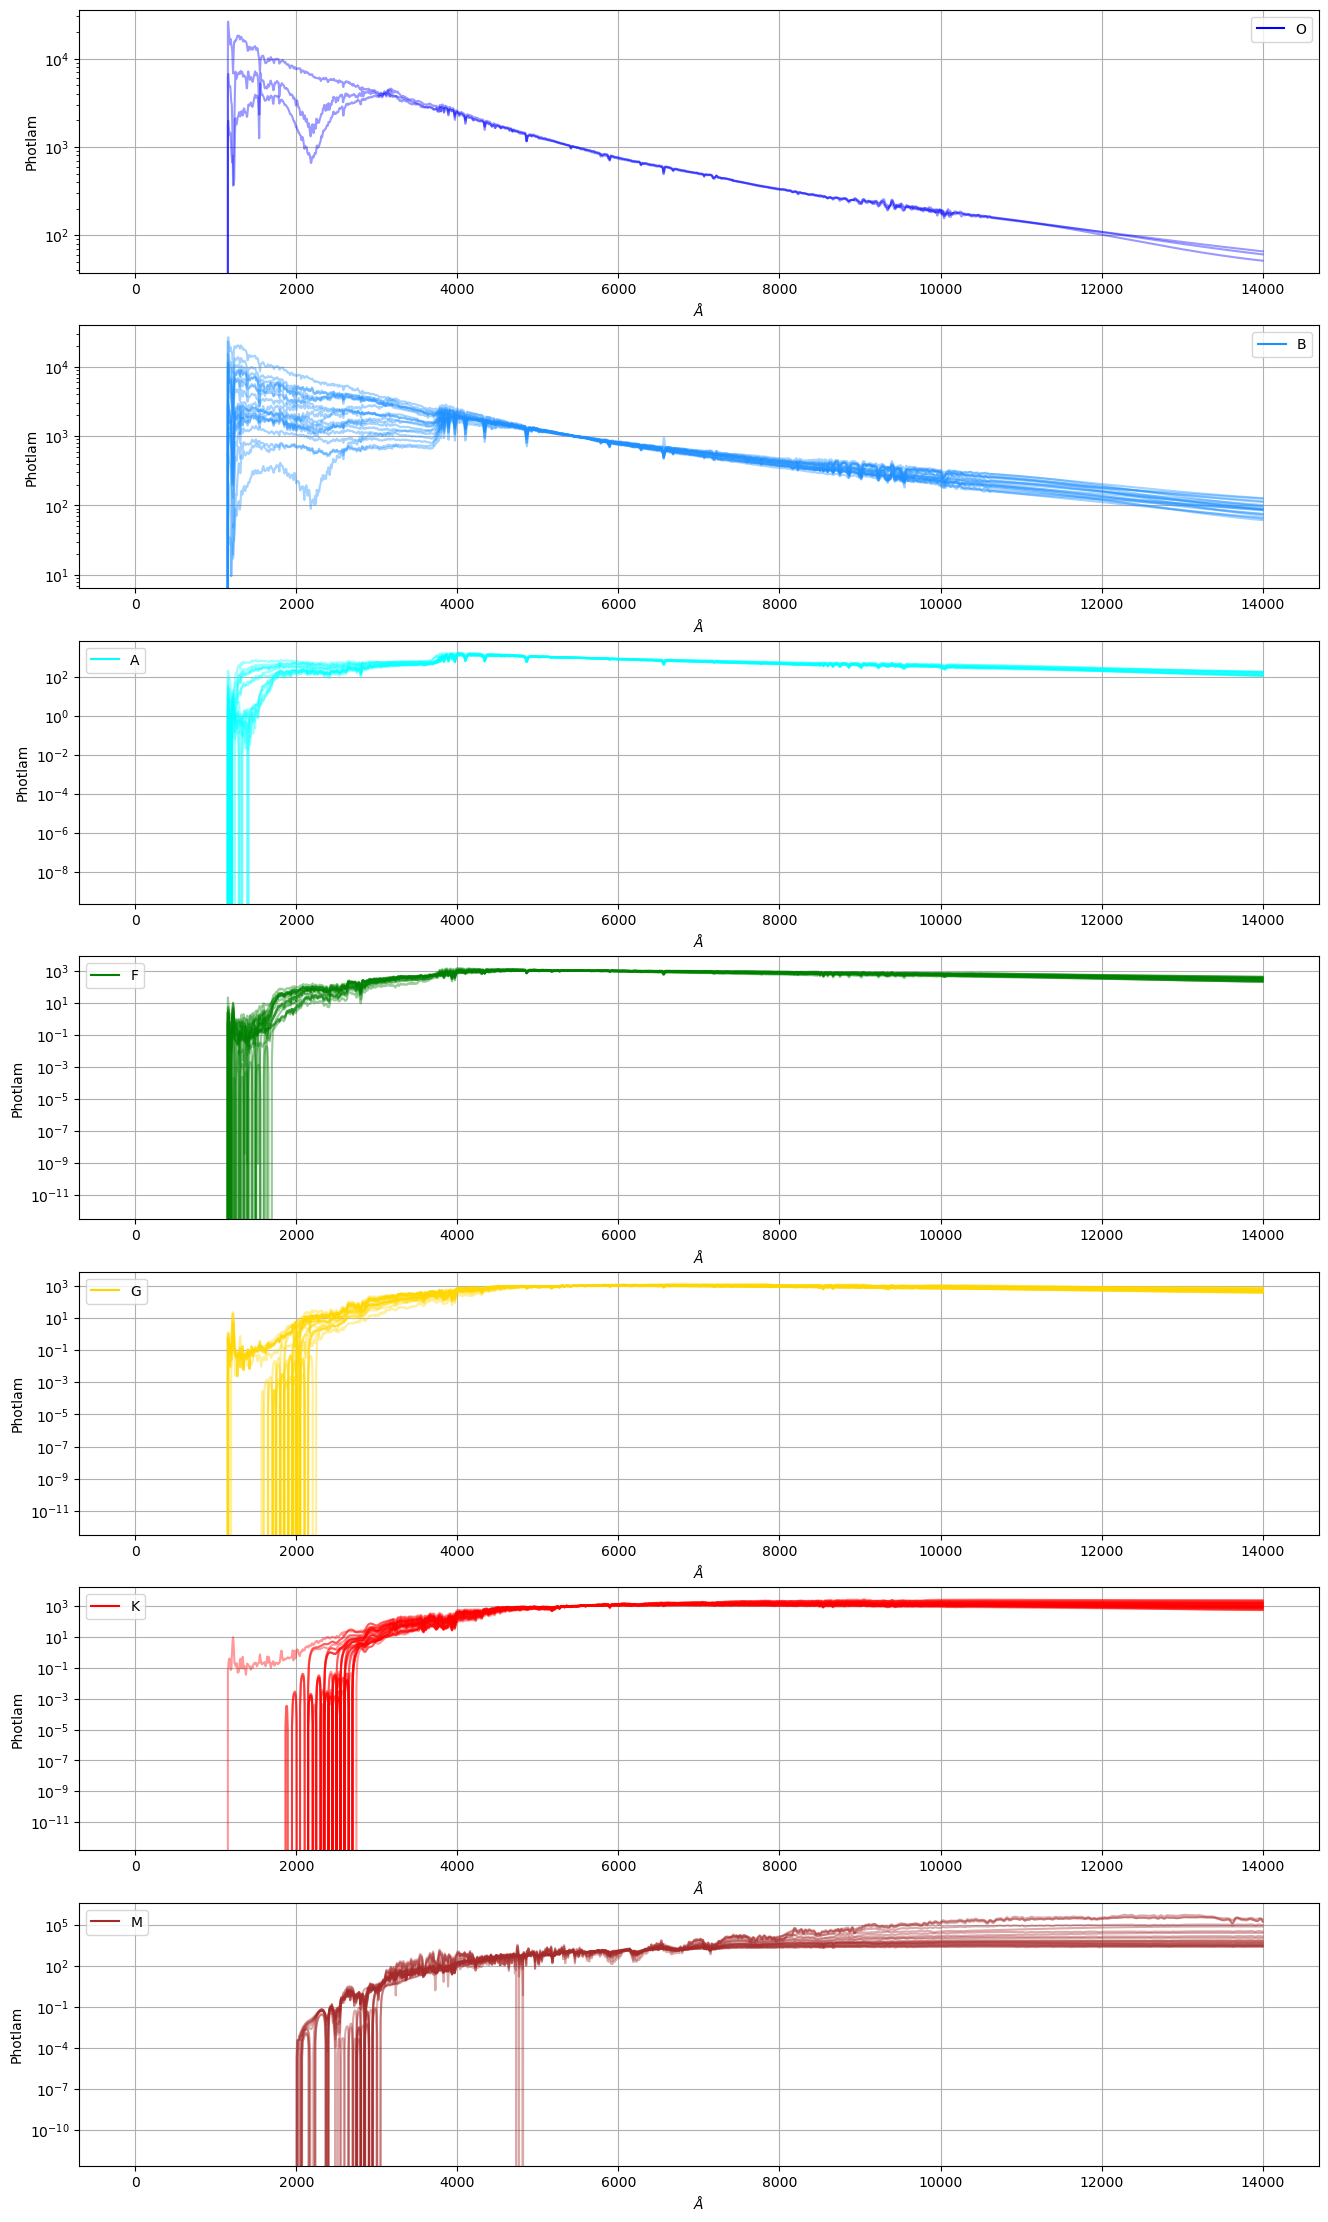

In [97]:
num_rows = len(spectral_types)
fig, axs = plt.subplots(num_rows, 1, figsize=(16,28))

for row,st in enumerate(spectral_types):
    for spec in spec_by_type[st]:
        #spec.convert('photlam')
        axs[row].plot(wl_baseline,spec,color=type_colors[st],alpha=0.4)
    axs[row].plot([],[],label=st,color=type_colors[st])
    axs[row].grid()
    #axs[row].set_yscale("log")
    axs[row].set_xlabel(wavelabel)
    axs[row].set_ylabel('Photlam')
    axs[row].legend()
    #axs[row].set_xlim(3000,11000)
    #axs[row].set_ylim(10,10000)
    axs[row].set_yscale("log")
            

# Now we assign an ID to each object and we also classify these IDs by spectral type 

In [99]:
id_dict = {}
for i,sed in enumerate(sed_dict.keys()):
    #id_dict[sed[:-5]] = '{0}'.format(i+1).zfill(len(str(len(sed_list))))
    id_dict[sed] = '{0}'.format(i+1).zfill(len(str(len(sed_list))))

In [100]:
id_by_type = {}
for i in range(len(spectral_types)):
    spec_type = spectral_types[i]
    
    id_list_ = []
    id_by_type[spec_type] = []
    for sed_ in id_dict.keys():
        if spec_type in type_dict[sed_]:
            id_list_.append(id_dict[sed_])
            id_by_type[spec_type].append(sed_)
    print(spec_type, id_list_)
    print(len(id_list_))
    print('-----------')

O ['001', '002', '060']
3
-----------
B ['003', '004', '005', '006', '007', '008', '046', '047', '061', '062', '063', '064', '106', '107', '114', '115', '116', '117', '118']
19
-----------
A ['009', '010', '011', '012', '013', '048', '049', '065', '066', '067', '068', '119', '120']
13
-----------
F ['014', '015', '016', '017', '018', '019', '020', '021', '022', '050', '051', '052', '069', '070', '071', '108', '109', '121', '122', '123']
20
-----------
G ['023', '024', '025', '026', '027', '028', '029', '030', '053', '054', '055', '056', '072', '073', '074', '075', '076', '077', '110', '124', '125', '126', '127']
23
-----------
K ['031', '032', '033', '034', '035', '036', '037', '057', '058', '059', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '111', '112', '128', '129', '130']
32
-----------
M ['038', '039', '040', '041', '042', '043', '044', '045', '095', '096', '097', '098', '099', '100', '101', '102', '103', '

# Calculate fluxes through total passbands 

Let's start with one spectrum of a type A star as example 

In [101]:
# Example with one spectrum 
test_type = 'O'
test_ind = 0
test_sed = spec_by_type[test_type][test_ind]
test_id = id_by_type[test_type][test_ind]
print(test_sed,test_id)

[ 0.          0.          0.         ... 60.76736832 60.75250626
 60.7376442 ] pickles_uk_1


In [102]:
obs_flux_t_dict = {}
obs_flux_std_dict = {}

for ised in sed_dict.keys():
    #print(ised)
    sed_ = sed_dict[ised]
    
    obstotal_dict_ = {}
    for filter_ in filters:
        obstotal_dict_[filter_] = []

    for filter_ in filters:
        #print(filter.name.upper())
        for i in range(n_sim):
            #total_pass = filter*atm_transp[i]
            #obs = S.Observation(spec,total_pass,force='taper')
            #obstotal_ = S.Observation(sed_,total_passband[filter_][i],force='taper')
            obstotal_ = sed_*total_passband[filter_][i]
            obstotal_dict_[filter_].append(obstotal_)
    
    obs_flux_t_dict[ised] = obstotal_dict_

    obstotal_dict_ref_ = {}
    for filter_ in filters:
        #obstotal_ = S.Observation(sed_,total_passband_ref[filter_],force='taper')
        obstotal_ = sed_*total_passband_ref[filter_]
        obstotal_dict_ref_[filter_] = obstotal_
        if ised=='pickles_uk_131':
            print(filter_,np.trapz(obstotal_,x=wl_baseline))
        
    obs_flux_std_dict[ised] = obstotal_dict_ref_
    

u 4028.6485812681626
g 309569.5063636218
r 980311.3494588856
i 1944043.390725123
z 2105783.4930714983
Y 1264389.0884182088


/tmp/ipykernel_5264/596370036.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(filter_,np.trapz(obstotal_,x=wl_baseline))


In [103]:
train_obs_flux_t_dict = {}
train_obs_flux_std_dict = {}

for ised in train_dict.keys():
    #print(ised)
    sed_ = train_dict[ised]
    
    obstotal_dict_ = {}
    for filter_ in filters:
        obstotal_dict_[filter_] = []

    for filter_ in filters:
        #print(filter.name.upper())
        for i in range(n_sim):
            #total_pass = filter*atm_transp[i]
            #obs = S.Observation(spec,total_pass,force='taper')
            #obstotal_ = S.Observation(sed_,total_passband[filter_][i],force='taper')
            obstotal_ = sed_*total_passband[filter_][i]
            obstotal_dict_[filter_].append(obstotal_)
    
    train_obs_flux_t_dict[ised] = obstotal_dict_

    obstotal_dict_ref_ = {}
    for filter_ in filters:
        #obstotal_ = S.Observation(sed_,total_passband_ref[filter_],force='taper')
        obstotal_ = sed_*total_passband_ref[filter_]
        obstotal_dict_ref_[filter_] = obstotal_
        
    train_obs_flux_std_dict[ised] = obstotal_dict_ref_

# Calculate magnitudes with our own function 

NOTE: we store the integrated fluxes, $\vec{\varphi}_i(t)$ and magnitudes, $\vec{m}_i(t)$, through the standard atmosphere separately for checking purposes. In general, we will only have the integrated fluxes through the current atmosphere 

In [104]:
Phi_AB

array([3.08923135e+12, 8.22196511e+12, 6.16230136e+12, 4.55383092e+12,
       3.08255162e+12, 1.64826545e+12])

In [105]:
phi_t_dict = {}
phi_std_dict = {}
mag_t_dict = {}
mag_std_dict = {}

for ised in sed_dict.keys():
    sed_ = sed_dict[ised]
    
    phi_dict_std_ = {}
    mag_dict_std_ = {}
    for index,filter_ in enumerate(filters):
        num_,mag_ = int_flux(sed_,total_passband_ref[filter_],
                        return_mag=True,PhiAB=Phi_AB[index])
        phi_dict_std_[filter_] = num_
        mag_dict_std_[filter_] = mag_
    phi_std_dict[ised] = phi_dict_std_
    mag_std_dict[ised] = mag_dict_std_
        
    phi_dict_t_ = {}
    mag_dict_t_ = {}
    
    for index,filter_ in enumerate(filters):
        phi_dict_t_[filter_] = []
        mag_dict_t_[filter_] = []
        for i in range(n_sim):
            num_,mag_ = int_flux(sed_,total_passband[filter_][i],
                           return_mag=True,PhiAB=Phi_AB[index])
            phi_dict_t_[filter_].append(num_)
            mag_dict_t_[filter_].append(mag_)
        
        phi_t_dict[ised] = phi_dict_t_
        mag_t_dict[ised] = mag_dict_t_
    #print('###########################################################')
    

/tmp/ipykernel_5264/1051446165.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(obs_flux_*renorm,x=obs_wave_)*Seff*exptime


In [106]:
train_phi_t_dict = {}
train_phi_std_dict = {}
train_mag_t_dict = {}
train_mag_std_dict = {}

for ised in train_dict.keys():
    sed_ = train_dict[ised]
    
    phi_dict_std_ = {}
    mag_dict_std_ = {}
    for index,filter_ in enumerate(filters):
        num_,mag_ = int_flux(sed_,total_passband_ref[filter_],
                        return_mag=True,PhiAB=Phi_AB[index])
        phi_dict_std_[filter_] = num_
        mag_dict_std_[filter_] = mag_
    train_phi_std_dict[ised] = phi_dict_std_
    train_mag_std_dict[ised] = mag_dict_std_
        
    phi_dict_t_ = {}
    mag_dict_t_ = {}
    
    for index,filter_ in enumerate(filters):
        phi_dict_t_[filter_] = []
        mag_dict_t_[filter_] = []
        for i in range(n_sim):
            num_,mag_ = int_flux(sed_,total_passband[filter_][i],
                           return_mag=True,PhiAB=Phi_AB[index])
            phi_dict_t_[filter_].append(num_)
            mag_dict_t_[filter_].append(mag_)
        
        train_phi_t_dict[ised] = phi_dict_t_
        train_mag_t_dict[ised] = mag_dict_t_
    #print('###########################################################')
    

/tmp/ipykernel_5264/1051446165.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(obs_flux_*renorm,x=obs_wave_)*Seff*exptime
/tmp/ipykernel_5264/1051446165.py:78: RuntimeWarning: divide by zero encountered in log10
  mab = -2.5*np.log10(num/den)


In [107]:
#phi_t_dict[test_id]

In [108]:
#phi_std_dict[test_id]

<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:24: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:24: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_5264/2231272956.py:23: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_5264/2231272956.py:24: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y


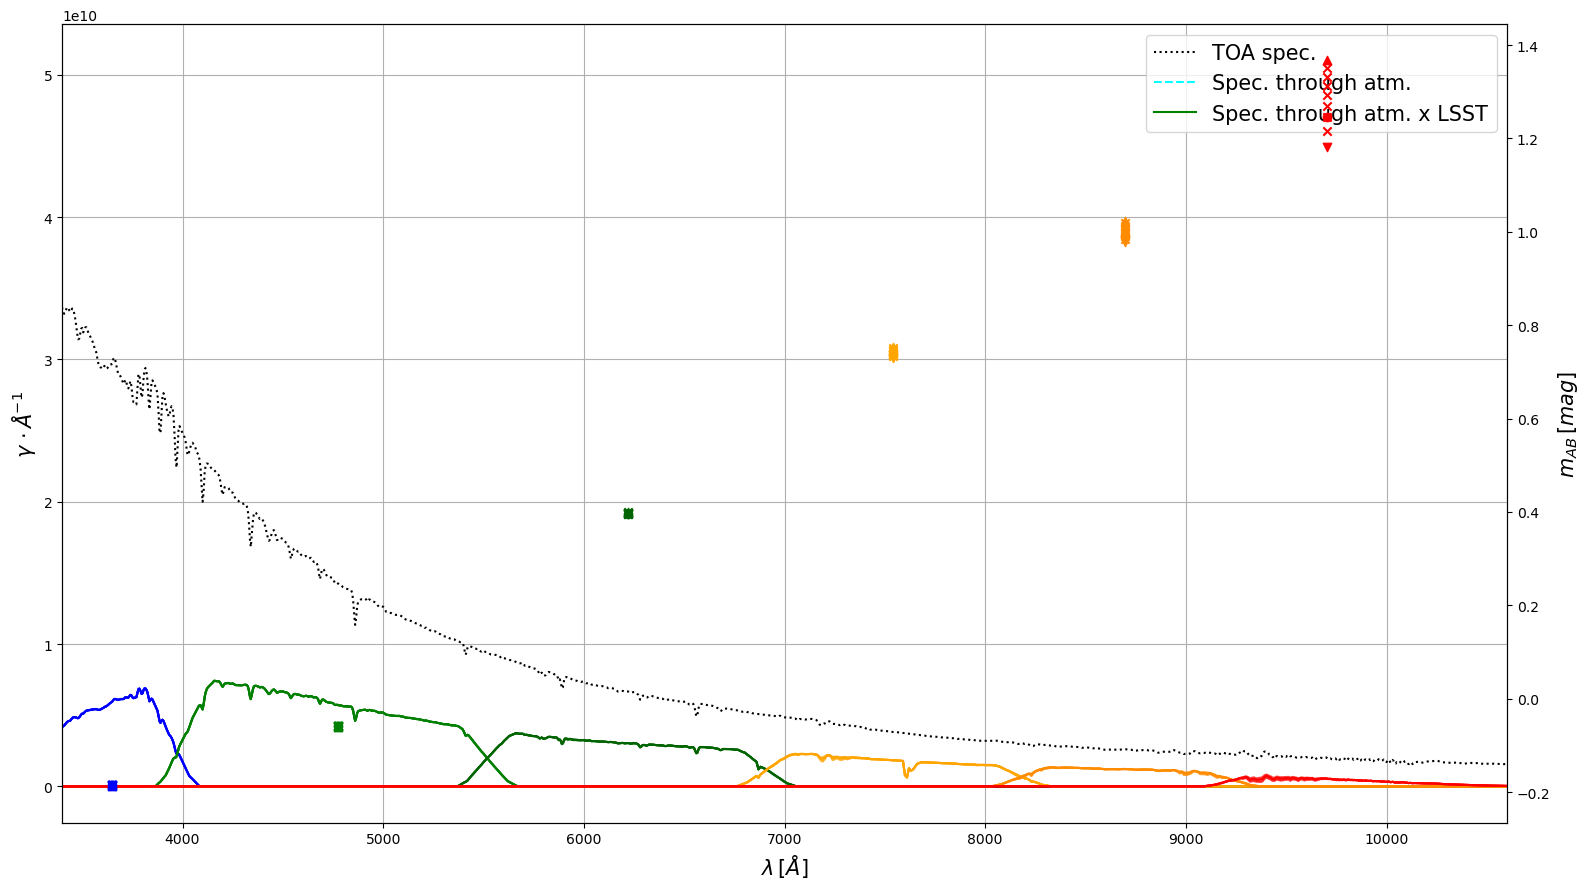

In [109]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(wl_baseline,sed_dict[test_id]*Seff*exptime,ls=':',color='k',alpha=1.0)

ax2 = ax1.twinx()

for index,filter_ in enumerate(filters):
    print(filter_)
    obs = obs_flux_std_dict[test_id][filter_]
    ax1.plot(wl_baseline,obs*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    for i in range(n_sim):
        obs = obs_flux_t_dict[test_id][filter_][i]
        if i==min_ind_ or i==max_ind_:
            alpha = 0.7
        else:
            alpha = 0.2
        ax1.plot(wl_baseline,obs*Seff*exptime,ls='-',color=filter_colors[index],alpha=alpha)
        

ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_ylim(0.,2e10)
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()
ax1.plot([],[],ls=':',color='k',label='TOA spec.')
ax1.plot([],[],ls='--',color='cyan',label='Spec. through atm.')
ax1.plot([],[],ls='-',color='g',label='Spec. through atm. x LSST')

for index,filter in enumerate(filters):
    ax2.scatter(eff_lambda[filter],mag_std_dict[test_id][filter],marker='o',color=filter_colors[index])
    for i in range(n_sim):
        if i==min_ind_:
            marker = 'v'
        elif i==max_ind_:
            marker = '^'
        else:
            marker = 'x'
        ax2.scatter(eff_lambda[filter],mag_t_dict[test_id][filter][i],marker=marker,color=filter_colors[index])

ax2.set_ylabel(r'$m_{AB} \, [mag]$',fontsize=15)
ax1.legend(fontsize=15)
plt.tight_layout()
#print(spec.fluxunits)

<>:24: SyntaxWarning: invalid escape sequence '\,'
<>:25: SyntaxWarning: invalid escape sequence '\g'
<>:24: SyntaxWarning: invalid escape sequence '\,'
<>:25: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_5264/1548713654.py:24: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_5264/1548713654.py:25: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y


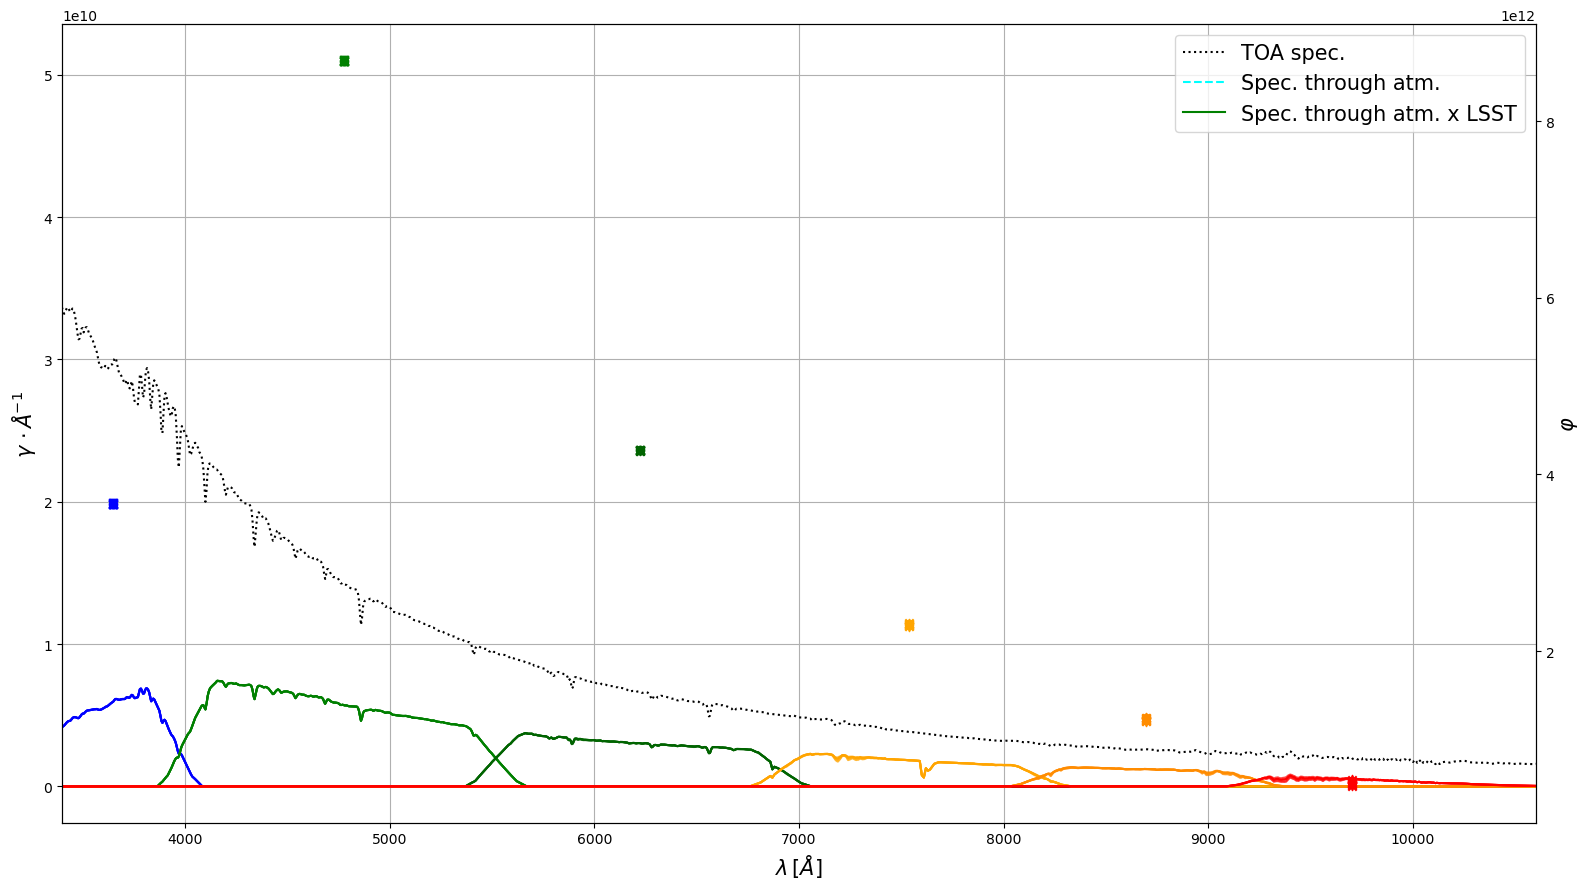

In [110]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(wl_baseline,sed_dict[test_id]*Seff*exptime,ls=':',color='k',alpha=1.0)

ax2 = ax1.twinx()

for index,filter_ in enumerate(filters):
    print(filter_)
    obs = obs_flux_std_dict[test_id][filter_]
    ax1.plot(wl_baseline,obs*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    for i in range(n_sim):
        obs = obs_flux_t_dict[test_id][filter_][i]
        if i==min_ind_ or i==max_ind_:
            alpha = 0.7
        else:
            alpha = 0.2
        ax1.plot(wl_baseline,obs*Seff*exptime,ls='-',color=filter_colors[index],alpha=alpha)
        

ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_ylim(0.,1.75e10)
#ax2.set_ylim(0,7.5e12)
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()
ax1.plot([],[],ls=':',color='k',label='TOA spec.')
ax1.plot([],[],ls='--',color='cyan',label='Spec. through atm.')
ax1.plot([],[],ls='-',color='g',label='Spec. through atm. x LSST')

for index,filter in enumerate(filters):
    ax2.scatter(eff_lambda[filter],phi_std_dict[test_id][filter],marker='o',color=filter_colors[index])
    for i in range(n_sim):
        if i==min_ind_:
            marker = '^'
        elif i==max_ind_:
            marker = 'v'
        else:
            marker = 'x'
        ax2.scatter(eff_lambda[filter],phi_t_dict[test_id][filter][i],marker=marker,color=filter_colors[index])

ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=15)
plt.tight_layout()
#print(spec.fluxunits)

# kNN

In [111]:
from sklearn.neighbors import NearestNeighbors

#from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
#from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [112]:
cat_test = spec_cat[np.where(np.array(sed_list)==test_id)[0][0]]

In [113]:
#phi_std_train = []
phi_std_test = []
#ids_train = []
for sed_ in sed_list:
    if sed_==test_id:
        phi_ = []
        for filter_ in filters:
            phi_.append(phi_std_dict[sed_][filter_])
        phi_std_test.append(phi_)
    #ids_train.append(sed_)
#phi_std_train = np.array(phi_std_train)
#len(phi_std_train),len(sed_list)

In [114]:
phi_std_test

[[np.float64(3662421484906.51),
  np.float64(8682499978308.344),
  np.float64(4277302302835.753),
  np.float64(2311617454616.163),
  np.float64(1237080058316.7844),
  np.float64(523492789536.0009)]]

In [116]:
phi_std_train = []
#phi_std_test = []
ids_train = []
for key_ in train_dict.keys():
    sed_ = train_dict[key_]
    phi_ = []
    for filter_ in filters:
        phi_.append(train_phi_std_dict[key_][filter_])
    phi_std_train.append(phi_)
    ids_train.append(key_)
phi_std_train = np.array(phi_std_train)
phi_std_train.shape

(1562, 6)

In [117]:
phi_std_train

array([[5.46615054e+25, 1.38034493e+27, 2.95691159e+27, 3.34390308e+27,
        2.82690429e+27, 1.56366836e+27],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00]], shape=(1562, 6))

In [118]:
phi_t_test = {}
for isim in range(n_sim):
    phi_t_test[isim] = []
    for sed_ in sed_list:
        
        phi_ = []
        if sed_==test_id:
            for filter_ in filters:
                phi_.append(phi_t_dict[sed_][filter_][isim])
            phi_t_test[isim].append(phi_)
        
    phi_t_test[isim] = np.array(phi_t_test[isim])

len(phi_t_test[0]),len(sed_list)

(1, 131)

In [119]:
phi_t_train = {}
for isim in range(n_sim):
    phi_t_train[isim] = []
    for key_ in train_dict.keys():
        sed_ = train_dict[key_]
        phi_ = []
        for filter_ in filters:
            phi_.append(train_phi_t_dict[key_][filter_][isim])
        phi_t_train[isim].append(phi_)

    phi_t_train[isim] = np.array(phi_t_train[isim])

len(phi_t_train[0]),len(phi_t_test[0]),len(sed_list)

(1562, 1, 131)

In [120]:
phi_t_train[0].shape,phi_t_test[0].shape

((1562, 6), (1, 6))

## Scale the training and test data

In [121]:
phi_t_train_scale = {}
phi_t_test_scale = {}
for isim in range(n_sim):
    scaler = StandardScaler()
    phi_t_train_scale[isim] = scaler.fit_transform(phi_t_train[isim])
    phi_t_test_scale[isim] = scaler.transform(phi_t_test[isim])

In [122]:
phi_t_train_scale[0].shape,phi_t_test_scale[0].shape

((1562, 6), (1, 6))

## Set up the neighrest neighbour finder 

In [123]:
knn = 10

In [124]:
distances_dict = {}
indices_dict = {}
for isim in range(n_sim):
    nbrs_ = NearestNeighbors(n_neighbors=knn, algorithm='ball_tree',metric='euclidean')
    nbrs_.fit(phi_t_train_scale[isim])
    distances_, indices_ = nbrs_.kneighbors(phi_t_test_scale[isim])
    distances_dict[isim] = distances_
    indices_dict[isim] = indices_

In [125]:
distances_dict, indices_dict

({0: array([[8.32667268e-17, 8.32667268e-17, 8.32667268e-17, 8.32667268e-17,
          8.32667268e-17, 8.32667268e-17, 8.32667268e-17, 8.32667268e-17,
          8.32667268e-17, 8.32667268e-17]]),
  1: array([[6.79869978e-17, 6.79869978e-17, 6.79869978e-17, 6.79869978e-17,
          6.79869978e-17, 6.79869978e-17, 6.79869978e-17, 6.79869978e-17,
          6.79869978e-17, 6.79869978e-17]]),
  2: array([[8.32667268e-17, 8.32667268e-17, 8.32667268e-17, 8.32667268e-17,
          8.32667268e-17, 8.32667268e-17, 8.32667268e-17, 8.32667268e-17,
          8.32667268e-17, 8.32667268e-17]]),
  3: array([[6.79869978e-17, 6.79869978e-17, 6.79869978e-17, 6.79869978e-17,
          6.79869978e-17, 6.79869978e-17, 6.79869978e-17, 6.79869978e-17,
          6.79869978e-17, 6.79869978e-17]]),
  4: array([[6.79869978e-17, 6.79869978e-17, 6.79869978e-17, 6.79869978e-17,
          6.79869978e-17, 6.79869978e-17, 6.79869978e-17, 6.79869978e-17,
          6.79869978e-17, 6.79869978e-17]]),
  5: array([[7.85046

In [126]:
categories

{'O': 10, 'B': 11, 'A': 12, 'F': 13, 'G': 14, 'K': 15, 'M': 16}

In [127]:
cat_test

np.int64(10)

In [128]:
spec_cat[indices_dict[0]]

IndexError: index 131 is out of bounds for axis 0 with size 131

In [129]:
nearest_ids = {}
for isim in range(n_sim):
    nearest_ids[isim] = [ids_train[i] for i in indices_dict[isim][0]]
nearest_ids[0],test_id

(['phoenixm15_54000',
  'phoenixm15_68000',
  'phoenixm15_5200',
  'phoenixm15_11800',
  'phoenixm15_49000',
  'phoenixm15_40000',
  'phoenixm20_20000',
  'phoenixm20_6700',
  'phoenixm15_5500',
  'phoenixm20_10800'],
 'pickles_uk_1')

In [130]:
weights_dict = {}
for isim in range(n_sim):
    weights_ = 1 / (distances_dict[isim][0] + 1e-10)  # Evitar división por cero
    weights_ = weights_ / np.sum(weights_)  # Normalizar pesos
    weights_dict[isim] = weights_

In [131]:
nearest_seds = {}
for isim in range(n_sim):
    nearest_seds[isim] = [np.array(train_dict[sed_]) for sed_ in nearest_ids[isim]]

In [132]:
nearest_seds[0]

[array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(13999,))]

In [133]:
weighted_sed_dict = {}
for isim in range(n_sim):
    weighted_sed_dict[isim] = np.sum(np.array(nearest_seds[isim]) * weights_dict[isim][:, np.newaxis], axis=0)

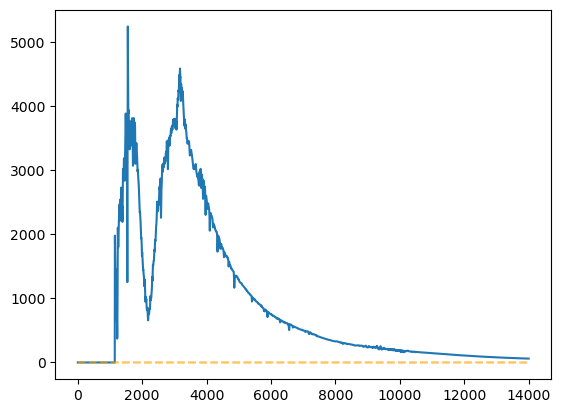

In [134]:
plt.plot(wl_baseline,test_sed)
for isim in range(n_sim):
    plt.plot(wl_baseline,weighted_sed_dict[isim],alpha=0.1,ls='--',color='orange')

## Now let us make pass the estimated SED through the standard and the current atmospheres 

In [155]:
est_flux_t_dict = {}
est_flux_std_dict = {}

    
obstotal_dict_ = {}
for filter_ in filters:
    obstotal_dict_[filter_] = []

for filter_ in filters:
    #print(filter.name.upper())
    for i in range(n_sim):
        #total_pass = filter*atm_transp[i]
        #obs = S.Observation(spec,total_pass,force='taper')
        #obstotal_ = S.Observation(sed_,total_passband[filter_][i],force='taper')
        obstotal_ = weighted_sed_dict[isim]*total_passband[filter_][i]
        obstotal_dict_[filter_].append(obstotal_)
    
est_flux_t_dict[test_id] = obstotal_dict_

obstotal_dict_ref_ = {}
for filter_ in filters:
    #obstotal_ = S.Observation(sed_,total_passband_ref[filter_],force='taper')
    obstotal_ = weighted_sed_dict[ref_ind_]*total_passband_ref[filter_]
    obstotal_dict_ref_[filter_] = obstotal_
    
est_flux_std_dict[test_id] = obstotal_dict_ref_
    

## And now we compute the integrated fluxes and magnitudes from the estimated spectrum 

In [156]:
Phi_t_dict = {}
Phi_std_dict = {}
Mag_t_dict = {}
Mag_std_dict = {}

    
phi_dict_std_ = {}
mag_dict_std_ = {}
for index,filter_ in enumerate(filters):
    num_,mag_ = int_flux(weighted_sed_dict[ref_ind_],total_passband_ref[filter_],
                    return_mag=True,PhiAB=Phi_AB[index])
    phi_dict_std_[filter_] = num_
    mag_dict_std_[filter_] = mag_
Phi_std_dict[test_id] = phi_dict_std_
Mag_std_dict[test_id] = mag_dict_std_
    
phi_dict_t_ = {}
mag_dict_t_ = {}

for index,filter_ in enumerate(filters):
    phi_dict_t_[filter_] = []
    mag_dict_t_[filter_] = []
    for i in range(n_sim):
        num_,mag_ = int_flux(weighted_sed_dict[isim],total_passband[filter_][i],
                       return_mag=True,PhiAB=Phi_AB[index])
        phi_dict_t_[filter_].append(num_)
        mag_dict_t_[filter_].append(mag_)
    
    Phi_t_dict[test_id] = phi_dict_t_
    Mag_t_dict[test_id] = mag_dict_t_
    #print('###########################################################')
    

/tmp/ipykernel_9025/1051446165.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(obs_flux_*renorm,x=obs_wave_)*Seff*exptime


<>:26: SyntaxWarning: invalid escape sequence '\,'
<>:27: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\,'
<>:27: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_9025/2388558072.py:26: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_9025/2388558072.py:27: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y


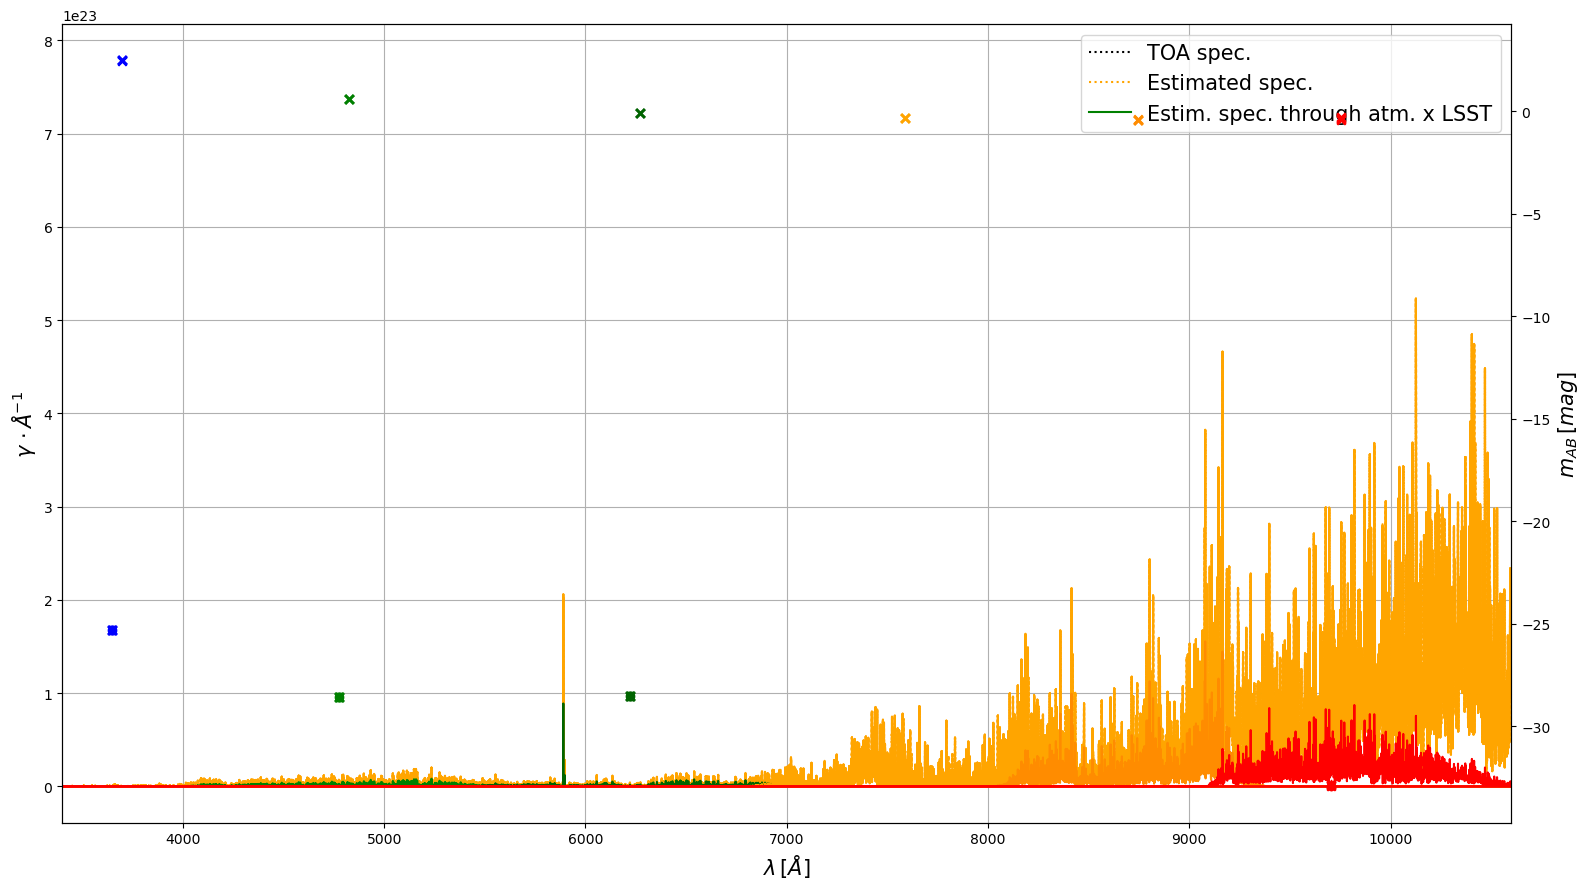

In [157]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(wl_baseline,sed_dict[test_id]*Seff*exptime,ls=':',color='k',alpha=1.0)
for isim in range(n_sim):
    ax1.plot(wl_baseline,weighted_sed_dict[isim]*Seff*exptime,ls=':',color='orange',alpha=1.0)

ax2 = ax1.twinx()

for index,filter_ in enumerate(filters):
    print(filter_)
    obs = est_flux_std_dict[test_id][filter_]
    ax1.plot(wl_baseline,obs*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    for i in range(n_sim):
        obs = obs_flux_t_dict[test_id][filter_][i]
        if i==min_ind_ or i==max_ind_:
            alpha = 0.7
        else:
            alpha = 0.2
        ax1.plot(wl_baseline,obs*Seff*exptime,ls='-',color=filter_colors[index],alpha=alpha)
        

ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_ylim(0.,1.75e10)
#ax2.set_ylim(0,7.5e12)
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()
ax1.plot([],[],ls=':',color='k',label='TOA spec.')
ax1.plot([],[],ls=':',color='orange',label='Estimated spec.')
ax1.plot([],[],ls='-',color='g',label='Estim. spec. through atm. x LSST')


for index,filter in enumerate(filters):
    ax2.scatter(eff_lambda[filter]+50,mag_std_dict[test_id][filter],marker='x',color=filter_colors[index])
    ax2.scatter(eff_lambda[filter],Mag_std_dict[test_id][filter],marker='o',color=filter_colors[index])
    for i in range(n_sim):
        if i==min_ind_:
            marker = 'v'
        elif i==max_ind_:
            marker = '^'
        else:
            marker = 'x'
        ax2.scatter(eff_lambda[filter]+50,mag_t_dict[test_id][filter][i],marker='x',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter],Mag_t_dict[test_id][filter][i],marker=marker,color=filter_colors[index])

ax2.set_ylabel(r'$m_{AB} \, [mag]$',fontsize=15)
ax1.legend(fontsize=15)
plt.tight_layout()
#print(spec.fluxunits)

<>:26: SyntaxWarning: invalid escape sequence '\,'
<>:27: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\,'
<>:27: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_7907/2565171688.py:26: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_7907/2565171688.py:27: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y


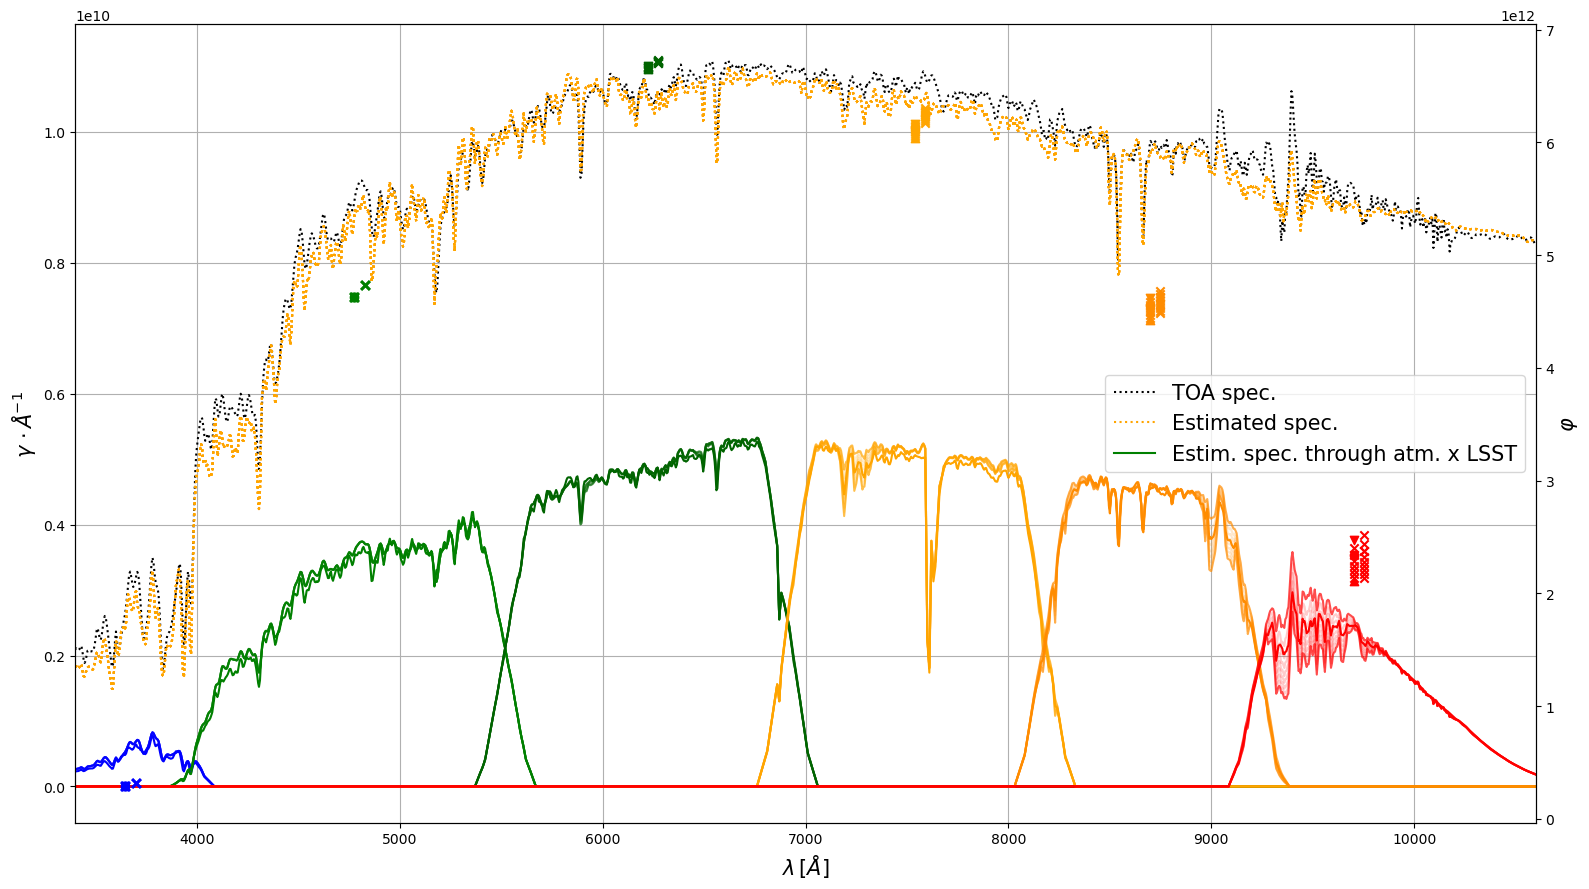

In [109]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(wl_baseline,sed_dict[test_id]*Seff*exptime,ls=':',color='k',alpha=1.0)
for isim in range(n_sim):
    ax1.plot(wl_baseline,weighted_sed_dict[isim]*Seff*exptime,ls=':',color='orange',alpha=1.0)

ax2 = ax1.twinx()

for index,filter_ in enumerate(filters):
    print(filter_)
    obs = est_flux_std_dict[test_id][filter_]
    ax1.plot(wl_baseline,obs*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    for i in range(n_sim):
        obs = obs_flux_t_dict[test_id][filter_][i]
        if i==min_ind_ or i==max_ind_:
            alpha = 0.7
        else:
            alpha = 0.2
        ax1.plot(wl_baseline,obs*Seff*exptime,ls='-',color=filter_colors[index],alpha=alpha)
        

ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_ylim(0.,1.75e10)
#ax2.set_ylim(0,7.5e12)
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()
ax1.plot([],[],ls=':',color='k',label='TOA spec.')
ax1.plot([],[],ls=':',color='orange',label='Estimated spec.')
ax1.plot([],[],ls='-',color='g',label='Estim. spec. through atm. x LSST')


for index,filter in enumerate(filters):
    ax2.scatter(eff_lambda[filter]+50,phi_std_dict[test_id][filter],marker='x',color=filter_colors[index])
    ax2.scatter(eff_lambda[filter],Phi_std_dict[test_id][filter],marker='o',color=filter_colors[index])
    for i in range(n_sim):
        if i==min_ind_:
            marker = 'v'
        elif i==max_ind_:
            marker = '^'
        else:
            marker = 'x'
        ax2.scatter(eff_lambda[filter]+50,phi_t_dict[test_id][filter][i],marker='x',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter],Phi_t_dict[test_id][filter][i],marker=marker,color=filter_colors[index])

ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=15)
plt.tight_layout()
#print(spec.fluxunits)

# Color compensation 

Let us introduce the notation and formalism: 

$$ m_{i,b}(t) = -2.5 \log_{10} \frac{\int F_i(\lambda) \, T_b(\lambda,t) \, S_{eff} \, t_{exp} \frac{d\lambda}{h\lambda}}{\int F_{AB} \, T_{tel,b}(\lambda) \, S_{eff} \, t_{exp} \frac{d\lambda}{h\lambda}} = -2.5 \log_{10} \frac{\varphi_{i,b}(t)}{\Phi_{AB,b}}$$ 

$$T_b (\lambda,t) = T_{tel,b}(\lambda) \cdot T_{atm}(\lambda,t) $$ 

$$T^{std}_b (\lambda) = T_{tel,b}(\lambda) \cdot T^{std}_{atm}(\lambda) $$ 

$$\vec{\varphi}^{\, corr}_i = \vec{\varphi}_i(t) \cdot \frac{\vec{\Phi}^{std}_i}{\vec{\Phi}_i(t)} $$

$$\Phi^{std}_{i,b} = \int \hat{F}_i(\lambda) \, T^{std}_b(\lambda) \, S_{eff} \, t_{exp} \, \frac{d\lambda}{h \lambda} $$

$$\Phi_{i,b}(t) = \int \hat{F}_i(\lambda) \, T_b(\lambda,t) \, S_{eff} \, t_{exp} \, \frac{d\lambda}{h \lambda} $$ 

$$\vec{\varphi}^{\, corr}_{i,\mu+1} = \vec{\varphi}_{i,\mu}(t) \cdot \frac{\vec{\Phi}^{std}_i}{\vec{\Phi}_i(t)} $$ 

We compute the integrated flux correction, 

$$ \vec{\varphi}^{\, corr}_i = \vec{\varphi}_i(t) \cdot \frac{\vec{\Phi}^{std}_i}{\vec{\Phi}_i(t)} \, . $$

In [110]:
phi_corr_dict = {}

phi_corr_dict[test_id] = {}
for filter in filters:
    phi_corr_dict[test_id][filter] = []
    for isim in range(n_sim):
        phi_corr_ = phi_t_dict[test_id][filter][isim]*Phi_std_dict[test_id][filter]/Phi_t_dict[test_id][filter][isim]
        phi_corr_dict[test_id][filter].append(phi_corr_)

In [111]:
Phi_std_dict[test_id][filter]

np.float64(2340022767759.237)

In [112]:
phi_corr_dict

{'pickles_uk_31': {'u': [np.float64(317813411643.3455),
   np.float64(317813418284.3479),
   np.float64(317813426597.8784),
   np.float64(317813436528.98206),
   np.float64(317813449437.08826),
   np.float64(317813575258.7629),
   np.float64(317814023850.6225),
   np.float64(317815312214.2968),
   np.float64(317815388086.4598)],
  'g': [np.float64(4737075807527.415),
   np.float64(4737078159075.797),
   np.float64(4737080575528.899),
   np.float64(4737083083831.225),
   np.float64(4737085734727.207),
   np.float64(4737093887961.631),
   np.float64(4737117653521.063),
   np.float64(4737182210907.759),
   np.float64(4737187920265.148)],
  'r': [np.float64(6723638047083.823),
   np.float64(6723646039854.115),
   np.float64(6723654024490.171),
   np.float64(6723661997376.095),
   np.float64(6723669952499.2295),
   np.float64(6723676678914.766),
   np.float64(6723681726927.653),
   np.float64(6723681095496.77),
   np.float64(6723688582184.255)],
  'i': [np.float64(6272991354781.46),
   np.f

In [113]:
phi_std_dict

{'pickles_uk_1': {'u': np.float64(3662421484906.51),
  'g': np.float64(8682499978308.344),
  'r': np.float64(4277302302835.753),
  'i': np.float64(2311617454616.163),
  'z': np.float64(1237080058316.7844),
  'Y': np.float64(523492789536.0009)},
 'pickles_uk_2': {'u': np.float64(3381449901899.6113),
  'g': np.float64(8515575229858.762),
  'r': np.float64(4197926347694.908),
  'i': np.float64(2319596167165.0776),
  'z': np.float64(1227206732713.1084),
  'Y': np.float64(506609824253.38556)},
 'pickles_uk_3': {'u': np.float64(3205061940029.061),
  'g': np.float64(8492176398502.571),
  'r': np.float64(4301783915812.8276),
  'i': np.float64(2391837477753.702),
  'z': np.float64(1305891340029.9634),
  'Y': np.float64(555903777028.5221)},
 'pickles_uk_4': {'u': np.float64(2705994238187.738),
  'g': np.float64(8036789459142.345),
  'r': np.float64(4430779608201.989),
  'i': np.float64(2507888540421.528),
  'z': np.float64(1449482175154.14),
  'Y': np.float64(613533000498.0278)},
 'pickles_uk_5'

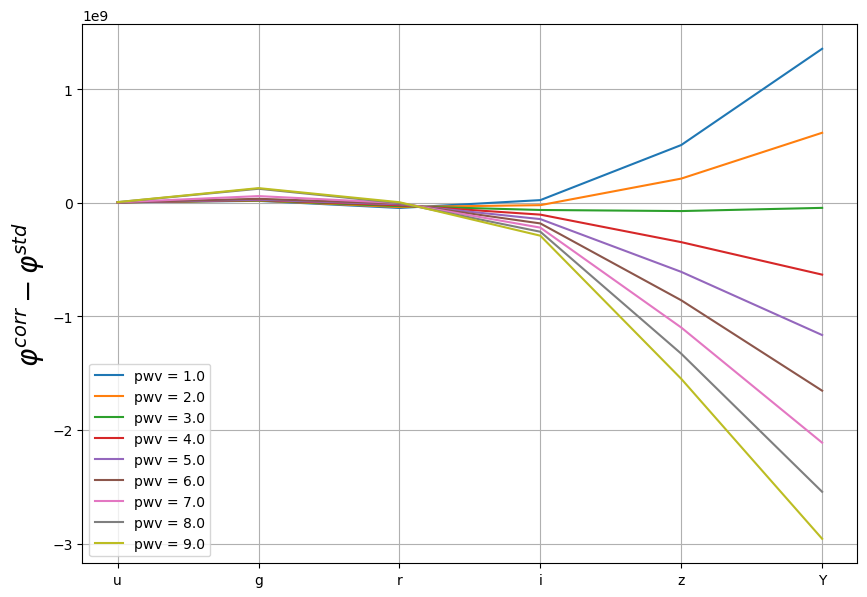

In [114]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111)

for isim in range(n_sim):
    delta_ = []
    for i,filter_ in enumerate(filters):
        delta_.append(phi_corr_dict[test_id][filter_][isim]-phi_std_dict[test_id][filter_])
    ax.plot(range(len(filters)),delta_,label='{0} = {1}'.format(variable_param,atm_vals[isim]))
ax.grid()
ax.set_ylabel(r'$\varphi^{corr}-\varphi^{std}$',fontsize=20)
xticks_ = ax.get_xticks()
ax.set_xticks(ticks=xticks_[1:-1])
ax.set_xticklabels(labels=filters)
ax.legend()

### We now work with magnitudes 

If we express the correction in magnitudes, we have 

$$\vec{m}^{\, corr}_i = \vec{m}_i(t)+\vec{\mathbb{m}}^{std}_i - \vec{\mathbb{m}}_i(t) $$

In [115]:
mag_corr_dict = {}

mag_corr_dict[test_id] = {}
for filter in filters:
    mag_corr_dict[test_id][filter] = []
    for isim in range(n_sim):
        mag_corr_ = mag_t_dict[test_id][filter][isim]+Mag_std_dict[test_id][filter]-Mag_t_dict[test_id][filter][isim]
        mag_corr_dict[test_id][filter].append(mag_corr_)

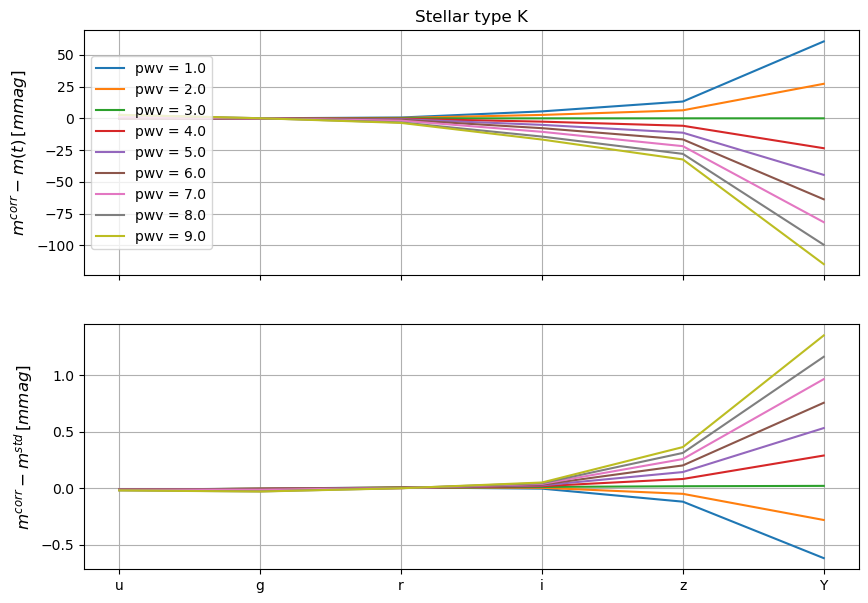

In [116]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 7))

for isim in range(n_sim):
    resi_ = []
    delta_ = []
    for i,filter_ in enumerate(filters):
        resi_.append((mag_corr_dict[test_id][filter_][isim]-mag_std_dict[test_id][filter_])*1000.)
        delta_.append((mag_corr_dict[test_id][filter_][isim]-mag_t_dict[test_id][filter_][isim])*1000.)
    ax1.plot(range(len(filters)),delta_,label='{0} = {1}'.format(variable_param,atm_vals[isim]))
    ax2.plot(range(len(filters)),resi_)


ax1.grid()
ax2.grid()
ax1.set_ylabel(r'$m^{corr}-m(t) \, [mmag]$',fontsize=12)
ax2.set_ylabel(r'$m^{corr}-m^{std} \, [mmag]$',fontsize=12)
xticks_ = ax2.get_xticks()
ax2.set_xticks(ticks=xticks_[1:-1])
ax2.set_xticklabels(labels=filters)
ax1.set_title('Stellar type {0}'.format(test_type))
ax1.legend(loc="center left")

plt.savefig(os.path.join(outdir_plots0,'colour_correction_kNN_type_{0}_{1}.png'.format(test_type,variable_param)))
